# Exploratory Data Analysis of X5 Group / Pyaterochka Store Turnover Dataset

Made by:
* Egor Dumalkin 252-2
* Matvey Veber 252-2


## 1. Abstract / Annotation

The project analyzes a store-level dataset related to X5 Group / Pyaterochka. The main goal of the work is to explore store turnover data, check data quality, identify anomalies, create useful derived features, visualize important patterns, and test hypotheses about store performance. The report follows the full exploratory data analysis process: dataset inspection, cleanup, descriptive statistics, general and detailed visual overview, data transformation, hypothesis testing, and final discussion.

The project was completed collaboratively by both team members. Egor Dumalkin mainly focused on the technical implementation of the analytical part, including data preprocessing, exploratory data analysis, descriptive statistics, feature engineering, visualizations, and hypothesis testing. Matvey Veber contributed to the analytical design of the project: together we searched for data anomalies, selected the most relevant plots, formulated the hypotheses, interpreted the results, and prepared the final conclusions. Matvey was also mainly responsible for developing the web interface, integrating the results into the project page, and preparing the final interactive version of the report.


## 2. Dataset Description

The dataset contains monthly observations for Pyaterochka stores. Each row represents one store in one month. The main target variable is `РТО`, which represents monthly retail turnover. Other fields describe store characteristics, local environment indicators, calendar fields, and categorical descriptors.

The notebook uses the local file `train_2.csv`. If the file is not available locally, the loading cell can download it from Google Drive.


If the required libraries are not installed, run the following cell:

In [1]:
%pip install -q pandas numpy matplotlib seaborn gdown scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [3]:
try:
    df = pd.read_csv("train_2.csv")
except FileNotFoundError:
    import gdown
    gdown.download(
        "https://drive.google.com/file/d/1D1-9nTE2rpu4uMukf1KYEkO2g8FaBTo0/view?usp=sharing",
        "train_2.csv",
        quiet=False,
    )
    df = pd.read_csv("train_2.csv")

df.head()


,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,...,"Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74209339.11


The first rows show that the dataset combines calendar fields, store-level features, local environment indicators, and the target variable `РТО`.


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485082 entries, 0 to 485081
Data columns (total 24 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   new_id                                     485082 non-null  int64  
 1   Год                                        485082 non-null  int64  
 2   Месяц                                      485082 non-null  int64  
 3   Среднее количество промо товаров в чеке    485082 non-null  float64
 4   Среднее количество товаров в чеке          485082 non-null  float64
 5   Среднее количество отмен                   485082 non-null  float64
 6   Рабочие часы в день                        485082 non-null  float64
 7   Дата открытия, категориальный              485082 non-null  object 
 8   Торговая площадь, категориальный           485082 non-null  object 
 9   Населенный пункт                           485082 non-null  object 
 10  Регион  

The output above shows the available columns, their data types, and the number of non-null values. It is the first check for wrong data types and explicit missing values.


In [5]:
n_rows, n_cols = df.shape
n_stores = df["new_id"].nunique()
period_summary = df[["Год", "Месяц"]].drop_duplicates().sort_values(["Год", "Месяц"])
rows_per_store = df.groupby("new_id").size()

overview = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Number of unique stores",
        "Number of unique year-month periods",
        "Minimum year",
        "Maximum year",
        "Minimum rows per store",
        "Maximum rows per store",
        "Median rows per store",
    ],
    "Value": [
        n_rows,
        n_cols,
        n_stores,
        period_summary.shape[0],
        df["Год"].min(),
        df["Год"].max(),
        rows_per_store.min(),
        rows_per_store.max(),
        rows_per_store.median(),
    ],
})

overview


,Metric,Value
0,Number of rows,485082.0
1,Number of columns,24.0
2,Number of unique stores,18657.0
3,Number of unique year-month periods,26.0
4,Minimum year,2023.0
5,Maximum year,2025.0
6,Minimum rows per store,26.0
7,Maximum rows per store,26.0
8,Median rows per store,26.0


The dataset is a balanced panel: the same stores are observed over multiple months. This is important because later hypotheses compare the same stores across years.


In [6]:
stores_by_period = pd.crosstab(df["Год"], df["Месяц"])
stores_by_period


Месяц,1,2,3,4,5,6,7,8,9,10,11,12
Год,,,,,,,,,,,,
2023,18657,18657,18657,18657,18657,18657,18657,18657,18657,18657,18657,18657
2024,18657,18657,18657,18657,18657,18657,18657,18657,18657,18657,18657,18657
2025,18657,18657,0,0,0,0,0,0,0,0,0,0


The table shows how many stores are available in each year-month period. The dataset includes all months of 2023 and 2024, and January-February of 2025.


In [7]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

column_types_summary = pd.DataFrame({
    "Feature type": ["Numeric columns", "Categorical or text columns"],
    "Count": [len(numeric_cols), len(categorical_cols)],
    "Columns": [numeric_cols, categorical_cols],
})

column_types_summary


,Feature type,Count,Columns
0,Numeric columns,20,"[new_id, Год, Месяц, Среднее количество промо ..."
1,Categorical or text columns,4,"[Дата открытия, категориальный, Торговая площа..."


Most columns are numeric. The main categorical fields describe store age category, store area category, settlement, and region. `Год` and `Месяц` are numeric but behave as calendar fields.


In [8]:
important_fields = pd.DataFrame({
    "Column": [
        "new_id",
        "Год", "Месяц",
        "РТО",
        "Рабочие часы в день",
        "Количество касс",
        "Трафик пеший, в час",
        "Трафик авто, в час",
        "Среднее количество товаров в чеке",
        "Среднее количество промо товаров в чеке",
        "Торговая площадь, категориальный",
        "Дата открытия, категориальный",
        "Регион",
        "Населенный пункт",
    ],
    "Meaning": [
        "Store identifier",
        "Observation year",
        "Observation month",
        "Monthly retail turnover",
        "Average working hours per day",
        "Number of cash registers",
        "Pedestrian traffic per hour near the store",
        "Car traffic per hour near the store",
        "Average number of items in a receipt",
        "Average number of promotional items in a receipt",
        "Categorical store area group",
        "Categorical store age group",
        "Russian region",
        "Settlement or city",
    ]
})

important_fields


,Column,Meaning
0,new_id,Store identifier
1,Год,Observation year
2,Месяц,Observation month
3,РТО,Monthly retail turnover
4,Рабочие часы в день,Average working hours per day
5,Количество касс,Number of cash registers
6,"Трафик пеший, в час",Pedestrian traffic per hour near the store
7,"Трафик авто, в час",Car traffic per hour near the store
8,Среднее количество товаров в чеке,Average number of items in a receipt
9,Среднее количество промо товаров в чеке,Average number of promotional items in a receipt


The fields above are the most important for the analysis. `РТО` is the target variable, while traffic, cash registers, working hours, receipt structure, region, and store area help explain differences in turnover.


## 3. Data Cleanup

The dataset has no explicit `NaN` values, but this does not mean that the data is clean. Some missing or incorrect values are encoded as zeros or physically impossible numbers. This section checks explicit missing values, data types, suspicious values, and the cleanup procedure.


In [9]:
missing_before = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_values"})
)
missing_before["missing_share"] = missing_before["missing_values"] / len(df)

missing_before.sort_values("missing_values", ascending=False)


,column,missing_values,missing_share
0,new_id,0,0.0
1,Год,0,0.0
22,Флаг алкогольной лицензии,0,0.0
21,Количество касс,0,0.0
20,Пятерочки (500 м),0,0.0
19,Продуктовые магазины (500 м),0,0.0
18,Остановки (300 м),0,0.0
17,Школы (300 м),0,0.0
16,Медицинские уч. и аптеки (300 м),0,0.0
15,"Маркетплейсы, доставки, постаматы (100 м)",0,0.0


There are no explicit missing values. Therefore, the cleanup process focuses on hidden missing values and impossible or suspicious values.


In [10]:
dtype_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [df[col].dtype for col in df.columns],
    "unique_values": [df[col].nunique() for col in df.columns],
})

dtype_summary


,column,dtype,unique_values
0,new_id,int64,18657
1,Год,int64,3
2,Месяц,int64,12
3,Среднее количество промо товаров в чеке,float64,279
4,Среднее количество товаров в чеке,float64,998
5,Среднее количество отмен,float64,2792
6,Рабочие часы в день,float64,34
7,"Дата открытия, категориальный",object,3
8,"Торговая площадь, категориальный",object,4
9,Населенный пункт,object,3270


The data types are generally suitable for EDA: numeric indicators are stored as numeric values, while region, settlement, and categorical descriptors are stored as object columns.


In [11]:
rules = {
    "work_hours_gt_24": df["Рабочие часы в день"] > 24,
    "work_hours_lt_6": df["Рабочие часы в день"] < 6,
    "cash_registers_zero": df["Количество касс"] == 0,
    "population_zero": df["Численность населения"] == 0,
    "households_zero": df["Количество домохозяйств"] == 0,
    "both_traffic_zero": (df["Трафик пеший, в час"] == 0) & (df["Трафик авто, в час"] == 0),
    "pedestrian_traffic_zero": df["Трафик пеший, в час"] == 0,
    "car_traffic_zero": df["Трафик авто, в час"] == 0,
    "promo_items_gt_total_items": (
        df["Среднее количество промо товаров в чеке"] >
        df["Среднее количество товаров в чеке"]
    ),
}

anomaly_summary = pd.DataFrame({
    "rows": {name: mask.sum() for name, mask in rules.items()},
    "stores": {name: df.loc[mask, "new_id"].nunique() for name, mask in rules.items()},
    "share": {name: mask.mean() for name, mask in rules.items()},
})

anomaly_summary.sort_values("rows", ascending=False)


,rows,stores,share
pedestrian_traffic_zero,29328,1128,0.060460
population_zero,20280,780,0.041807
car_traffic_zero,18148,698,0.037412
both_traffic_zero,17498,673,0.036072
cash_registers_zero,3718,143,0.007665
work_hours_gt_24,1976,76,0.004074
households_zero,832,32,0.001715
work_hours_lt_6,754,29,0.001554
promo_items_gt_total_items,0,0,0.000000


The main problems are hidden missing values and impossible values: working hours above 24, very low working hours, zero population, zero traffic, and zero cash registers. These values are suspicious because they contradict either business logic or the meaning of the field.


In [12]:
rto_p90 = df["РТО"].quantile(0.90)
zero_traffic_high_rto = df[
    (df["Трафик пеший, в час"] == 0) &
    (df["Трафик авто, в час"] == 0) &
    (df["РТО"] >= rto_p90)
]

zero_traffic_high_rto[[
    "new_id", "Год", "Месяц",
    "Трафик пеший, в час", "Трафик авто, в час",
    "РТО", "Населенный пункт", "Регион"
]].sort_values("РТО", ascending=False).head(10)


,new_id,Год,Месяц,"Трафик пеший, в час","Трафик авто, в час",РТО,Населенный пункт,Регион
183990,8271,2024,7,0,0,4.082478e+08,Лосево п. ж/д ст.,Ленинградская обл
348882,15642,2023,7,0,0,4.070723e+08,Куйвози д,Ленинградская обл
483511,21678,2024,7,0,0,4.068489e+08,Раменское г,Московская обл
483509,21678,2024,6,0,0,3.996859e+08,Раменское г,Московская обл
483513,21678,2024,8,0,0,3.802769e+08,Раменское г,Московская обл
348880,15642,2023,6,0,0,3.798557e+08,Куйвози д,Ленинградская обл
183993,8271,2024,8,0,0,3.766043e+08,Лосево п. ж/д ст.,Ленинградская обл
348883,15642,2024,7,0,0,3.745532e+08,Куйвози д,Ленинградская обл
183988,8271,2024,6,0,0,3.730848e+08,Лосево п. ж/д ст.,Ленинградская обл
483510,21678,2023,7,0,0,3.721314e+08,Раменское г,Московская обл


Some stores have zero pedestrian and car traffic but high turnover. This suggests that zero traffic values should not always be interpreted as true zero traffic; in many cases they are likely hidden missing values or data collection errors.


In [13]:
num_cols_for_iqr = df.select_dtypes(include="number").columns.drop(
    ["new_id", "Год", "Месяц", "Флаг алкогольной лицензии"]
)

iqr_report = []
for col in num_cols_for_iqr:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    iqr_report.append({
        "column": col,
        "lower": lower,
        "upper": upper,
        "outlier_rows": mask.sum(),
        "outlier_share": mask.mean(),
    })

pd.DataFrame(iqr_report).sort_values("outlier_rows", ascending=False)


,column,lower,upper,outlier_rows,outlier_share
2,Среднее количество отмен,-2.510000e+02,6.130000e+02,69887,0.144073
4,Численность населения,-1.066698e+06,1.825550e+06,41340,0.085223
7,"Трафик авто, в час",-2.050000e+02,5.390000e+02,31330,0.064587
15,РТО,-1.796954e+07,1.800100e+08,26805,0.055259
14,Количество касс,1.500000e+00,1.350000e+01,25896,0.053385
8,"Маркетплейсы, доставки, постаматы (100 м)",-2.000000e+00,6.000000e+00,19292,0.039771
6,"Трафик пеший, в час",-2.900000e+01,2.830000e+02,18642,0.038431
11,Остановки (300 м),-4.500000e+00,7.500000e+00,13546,0.027925
9,Медицинские уч. и аптеки (300 м),-4.500000e+00,7.500000e+00,12792,0.026371
10,Школы (300 м),-1.500000e+00,2.500000e+00,12220,0.025192


The IQR report is a statistical outlier check. It does not automatically mean that all listed values are errors. For example, high turnover may be a real business effect, while impossible working hours must be cleaned.


In [14]:
df["rto_store_median"] = df.groupby("new_id")["РТО"].transform("median")
df["rto_to_store_median"] = df["РТО"] / df["rto_store_median"]

rto_spikes = df[df["rto_to_store_median"] > 4]
rto_drops = df[df["rto_to_store_median"] < 0.25]

pd.DataFrame({
    "case": ["RTO > 4 times store median", "RTO < 0.25 times store median"],
    "rows": [len(rto_spikes), len(rto_drops)],
    "stores": [rto_spikes["new_id"].nunique(), rto_drops["new_id"].nunique()],
})


,case,rows,stores
0,RTO > 4 times store median,100,27
1,RTO < 0.25 times store median,129,125


Turnover outliers are treated differently from impossible feature values. Since `РТО` is the target variable, we do not replace it automatically. High or low turnover can be caused by real business events, seasonality, tourist locations, or incomplete months. These cases are analyzed but not imputed.


In [15]:
clean = df.copy()

clean["is_bad_work_hours"] = clean["Рабочие часы в день"] > 24
clean["is_low_work_hours"] = clean["Рабочие часы в день"] < 6
clean["is_zero_population"] = clean["Численность населения"] == 0
clean["is_zero_households"] = clean["Количество домохозяйств"] == 0
clean["is_zero_both_traffic"] = (
    (clean["Трафик пеший, в час"] == 0) &
    (clean["Трафик авто, в час"] == 0)
)
clean["is_zero_cash_registers"] = clean["Количество касс"] == 0

clean.loc[clean["Рабочие часы в день"] > 24, "Рабочие часы в день"] = np.nan
clean.loc[clean["Рабочие часы в день"] < 6, "Рабочие часы в день"] = np.nan
clean.loc[clean["Численность населения"] == 0, "Численность населения"] = np.nan
clean.loc[clean["Количество домохозяйств"] == 0, "Количество домохозяйств"] = np.nan
clean.loc[clean["Количество касс"] == 0, "Количество касс"] = np.nan

traffic_zero = (
    (clean["Трафик пеший, в час"] == 0) &
    (clean["Трафик авто, в час"] == 0)
)
clean.loc[traffic_zero, ["Трафик пеший, в час", "Трафик авто, в час"]] = np.nan


Before imputation, clearly incorrect values are replaced with `NaN`. At the same time, flag columns preserve information about where the original anomalies were found.


In [16]:
def fill_by_group_median(data, col, group_levels):
    result = data[col].copy()
    for group_cols in group_levels:
        group_median = data.groupby(group_cols)[col].transform("median")
        result = result.fillna(group_median)
    return result.fillna(data[col].median())

clean["Рабочие часы в день"] = fill_by_group_median(
    clean,
    "Рабочие часы в день",
    [["Регион", "Торговая площадь, категориальный"], ["Торговая площадь, категориальный"], ["Регион"]]
)

clean["Численность населения"] = fill_by_group_median(
    clean,
    "Численность населения",
    [["Регион", "Населенный пункт"], ["Регион"]]
)

clean["Количество домохозяйств"] = fill_by_group_median(
    clean,
    "Количество домохозяйств",
    [["Регион", "Населенный пункт"], ["Регион"]]
)

clean["Количество касс"] = fill_by_group_median(
    clean,
    "Количество касс",
    [["Регион", "Торговая площадь, категориальный"], ["Торговая площадь, категориальный"]]
)

for col in ["Трафик пеший, в час", "Трафик авто, в час"]:
    clean[col] = fill_by_group_median(
        clean,
        col,
        [["Регион", "Населенный пункт", "Торговая площадь, категориальный"], ["Регион", "Населенный пункт"], ["Регион"]]
    )


Group medians are used because they are robust to outliers and preserve the structure of similar stores or locations better than a single global mean.


In [17]:
cleanup_check = pd.DataFrame({
    "check": [
        "Remaining explicit NaN values",
        "Working hours below 6",
        "Working hours above 24",
        "Zero cash registers",
        "Zero population",
        "Both traffic values equal zero",
    ],
    "rows": [
        clean.isna().sum().sum(),
        (clean["Рабочие часы в день"] < 6).sum(),
        (clean["Рабочие часы в день"] > 24).sum(),
        (clean["Количество касс"] == 0).sum(),
        (clean["Численность населения"] == 0).sum(),
        ((clean["Трафик пеший, в час"] == 0) & (clean["Трафик авто, в час"] == 0)).sum(),
    ]
})

cleanup_check


,check,rows
0,Remaining explicit NaN values,0
1,Working hours below 6,0
2,Working hours above 24,0
3,Zero cash registers,0
4,Zero population,0
5,Both traffic values equal zero,0


In [18]:
clean.dtypes.reset_index().rename(columns={"index": "column", 0: "dtype"})


,column,dtype
0,new_id,int64
1,Год,int64
2,Месяц,int64
3,Среднее количество промо товаров в чеке,float64
4,Среднее количество товаров в чеке,float64
5,Среднее количество отмен,float64
6,Рабочие часы в день,float64
7,"Дата открытия, категориальный",object
8,"Торговая площадь, категориальный",object
9,Населенный пункт,object


After cleanup, the selected hidden missing values and impossible working-hour values are removed from the cleaned dataframe. The anomaly flags remain available for later analysis.


## 4. Descriptive Statistics

This section provides descriptive statistics for the most important numerical fields. The table includes mean, median, and standard deviation.


In [19]:
stats_cols = [
    "РТО",
    "Количество касс",
    "Трафик пеший, в час",
    "Трафик авто, в час",
    "Рабочие часы в день",
]

descriptive_stats = clean[stats_cols].agg(["mean", "median", "std"]).T
descriptive_stats


,mean,median,std
РТО,8.853480e+07,75210937.85,4.824900e+07
Количество касс,7.735274e+00,7.00,2.985716e+00
"Трафик пеший, в час",1.370960e+02,124.00,7.671127e+01
"Трафик авто, в час",2.083980e+02,144.00,2.014868e+02
Рабочие часы в день,1.441716e+01,14.00,2.979626e+00


The selected columns describe turnover, store capacity, traffic, and working schedule. The comparison between mean and median is useful because several variables are skewed and contain high values.


## 5. General Visual Overview

This section gives a first visual overview of the cleaned dataset. It includes histograms, boxplots, line plots, bar plots, and traffic comparisons.


### 5.1 Target Variable Distribution

Turnover is a monetary variable and usually has a long right tail. We compare the original turnover distribution with a logarithmic transformation used only for visualization.


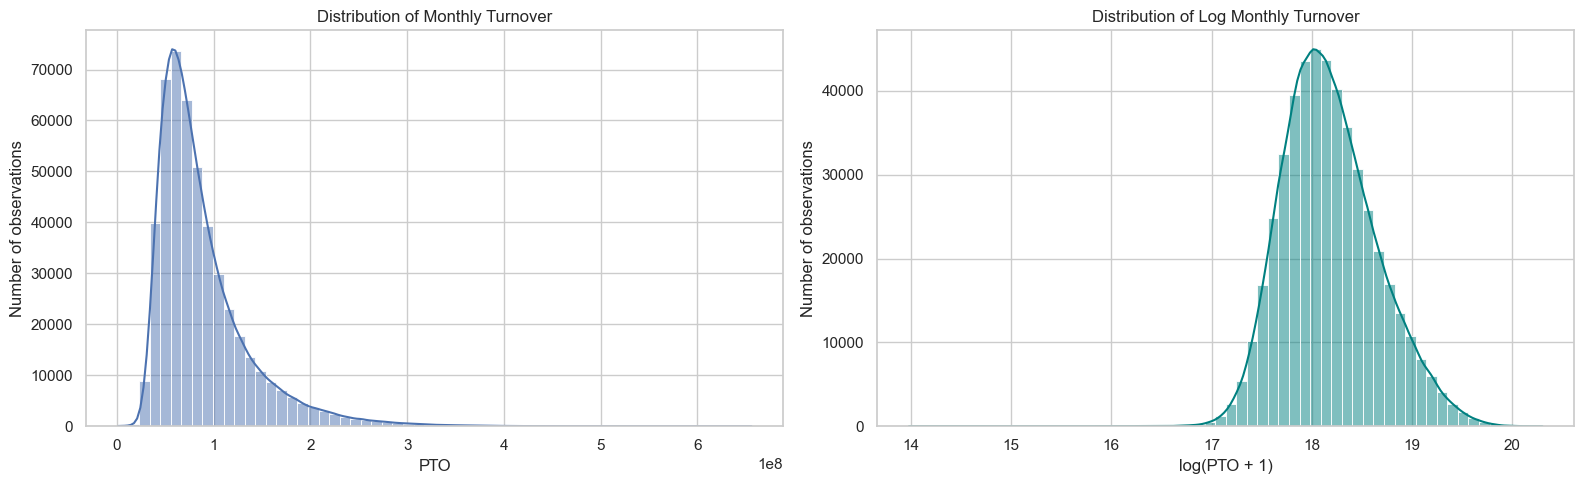

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(clean["РТО"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Monthly Turnover")
axes[0].set_xlabel("РТО")
axes[0].set_ylabel("Number of observations")

sns.histplot(np.log1p(clean["РТО"]), bins=60, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Distribution of Log Monthly Turnover")
axes[1].set_xlabel("log(РТО + 1)")
axes[1].set_ylabel("Number of observations")

plt.tight_layout()
plt.show()


The original turnover distribution is strongly right-skewed. The logarithmic transformation makes the central part of the distribution easier to inspect.


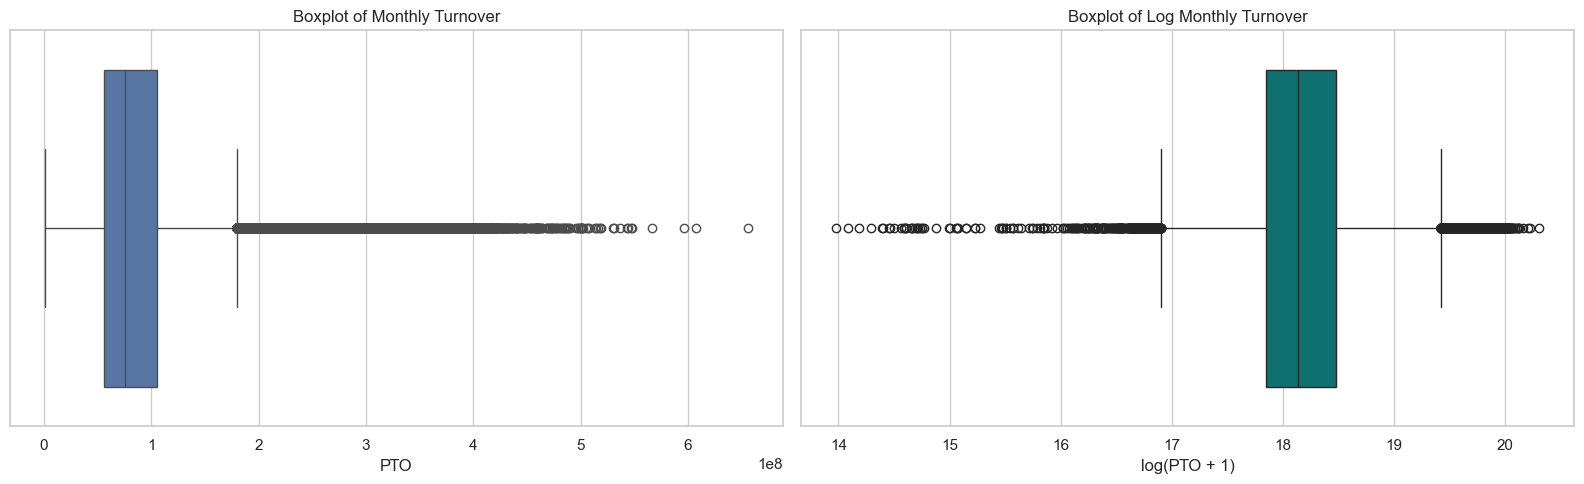

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x=clean["РТО"], ax=axes[0])
axes[0].set_title("Boxplot of Monthly Turnover")
axes[0].set_xlabel("РТО")

sns.boxplot(x=np.log1p(clean["РТО"]), ax=axes[1], color="teal")
axes[1].set_title("Boxplot of Log Monthly Turnover")
axes[1].set_xlabel("log(РТО + 1)")

plt.tight_layout()
plt.show()


The boxplots confirm that turnover has a large number of high values. These values are not automatically removed because they may represent real stores with high sales.


### 5.2 Time Coverage and Monthly Turnover

The next plots compare monthly mean and median turnover by year. This helps identify seasonality and differences between years.


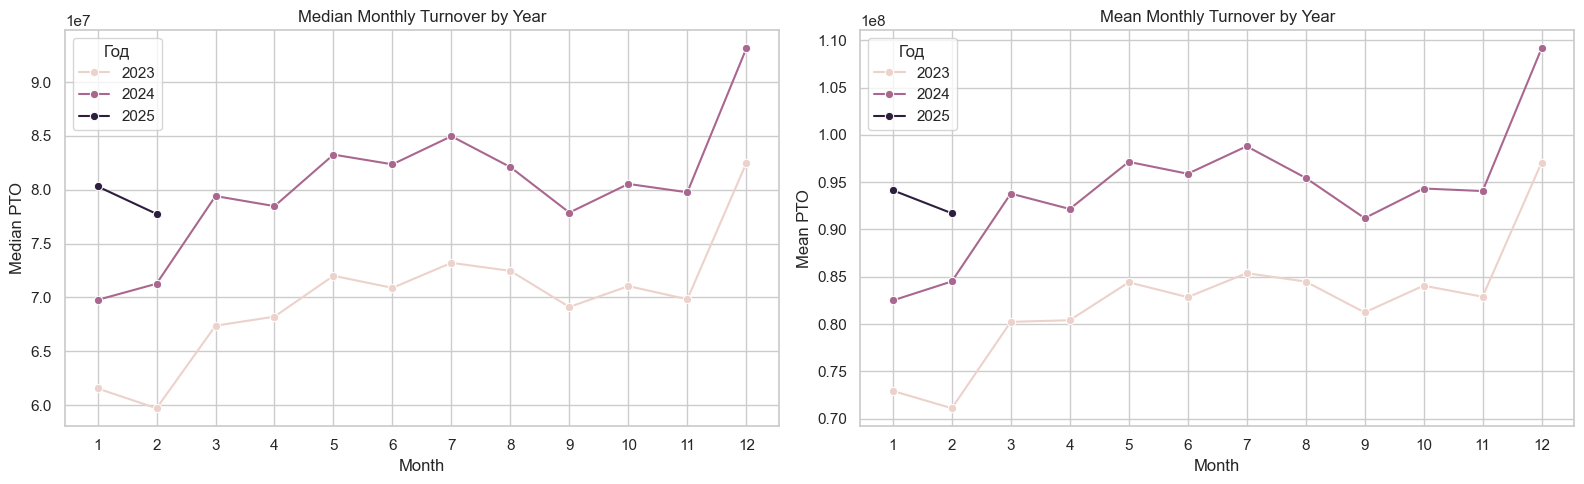

In [22]:
monthly_turnover = (
    clean.groupby(["Год", "Месяц"])["РТО"]
    .agg(mean="mean", median="median")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=monthly_turnover, x="Месяц", y="median", hue="Год", marker="o", ax=axes[0])
axes[0].set_title("Median Monthly Turnover by Year")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Median РТО")
axes[0].set_xticks(range(1, 13))

sns.lineplot(data=monthly_turnover, x="Месяц", y="mean", hue="Год", marker="o", ax=axes[1])
axes[1].set_title("Mean Monthly Turnover by Year")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean РТО")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


The line plots show turnover dynamics across months. Mean values are more sensitive to very large stores, while medians describe a more typical store-month.


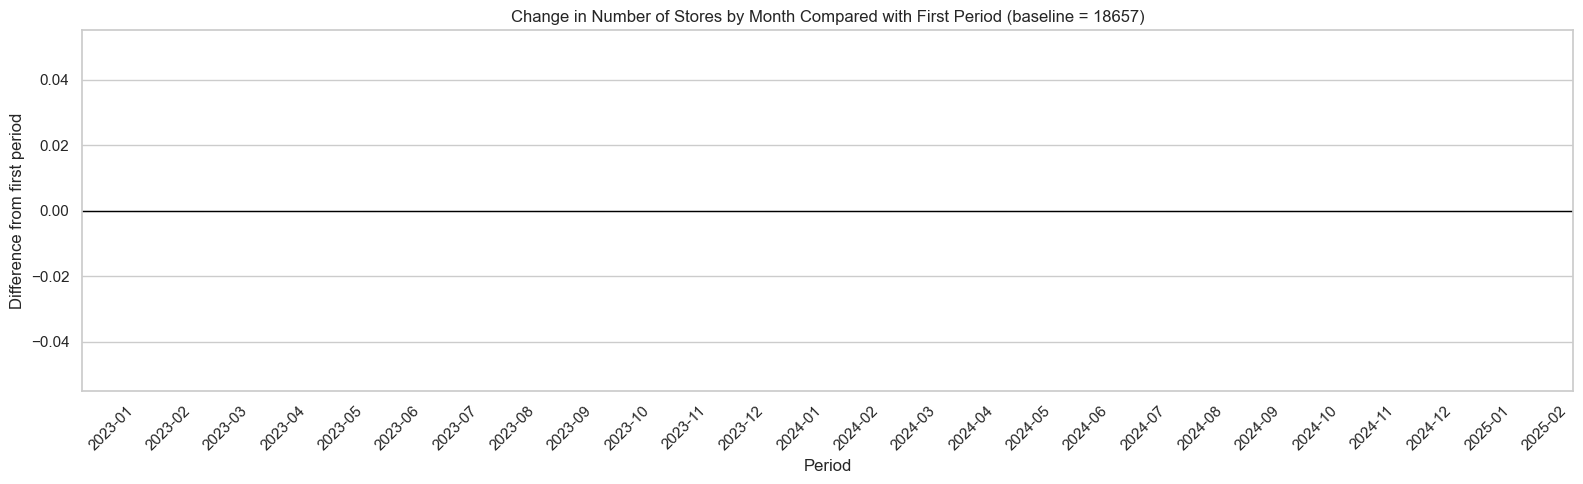

In [23]:
stores_by_period_plot = clean.groupby(["Год", "Месяц"])["new_id"].nunique().reset_index()
stores_by_period_plot["period"] = stores_by_period_plot["Год"].astype(str) + "-" + stores_by_period_plot["Месяц"].astype(str).str.zfill(2)

baseline_stores = stores_by_period_plot["new_id"].iloc[0]
stores_by_period_plot["difference_from_first_period"] = stores_by_period_plot["new_id"] - baseline_stores

plt.figure(figsize=(16, 5))
sns.barplot(data=stores_by_period_plot, x="period", y="difference_from_first_period", color="steelblue")
plt.axhline(0, color="black", linewidth=1)
plt.title(f"Change in Number of Stores by Month Compared with First Period (baseline = {baseline_stores})")
plt.xlabel("Period")
plt.ylabel("Difference from first period")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The number of stores is stable across periods. This supports later same-store comparisons because the panel structure is balanced.


### 5.3 Store Categories and Numerical Features

The following plots show the distribution of categorical store descriptors and several important numerical fields.


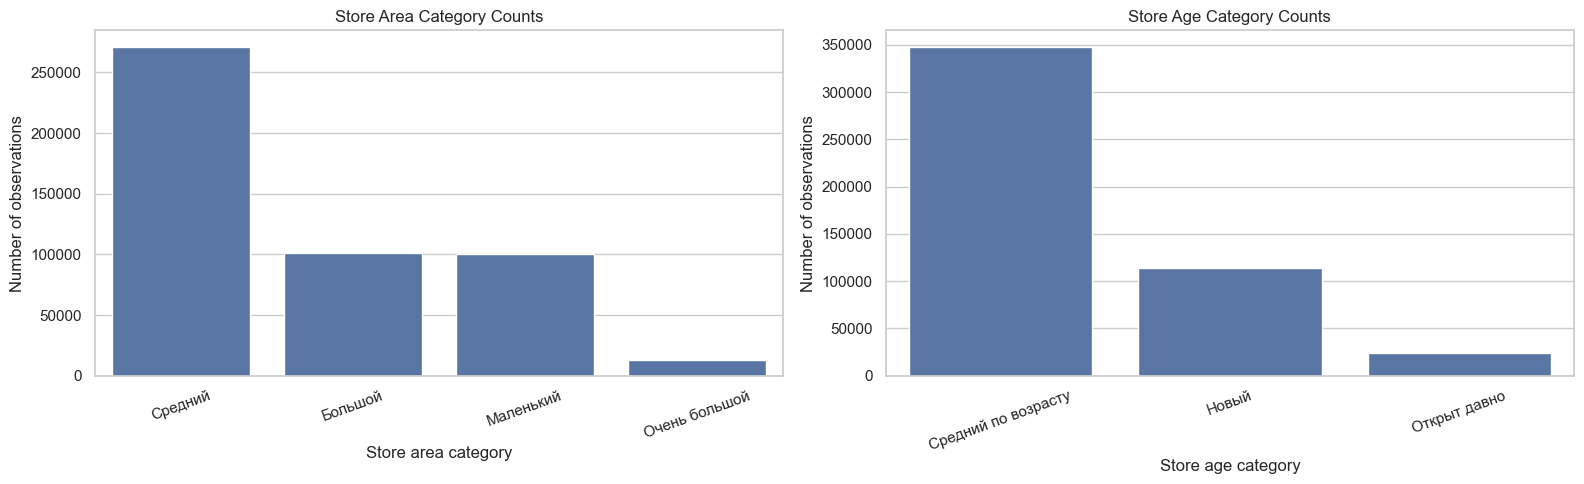

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(
    data=clean,
    x="Торговая площадь, категориальный",
    order=clean["Торговая площадь, категориальный"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Store Area Category Counts")
axes[0].set_xlabel("Store area category")
axes[0].set_ylabel("Number of observations")
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(
    data=clean,
    x="Дата открытия, категориальный",
    order=clean["Дата открытия, категориальный"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Store Age Category Counts")
axes[1].set_xlabel("Store age category")
axes[1].set_ylabel("Number of observations")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


Most observations belong to medium store area and medium store age categories. These categories are later used for grouped comparisons.


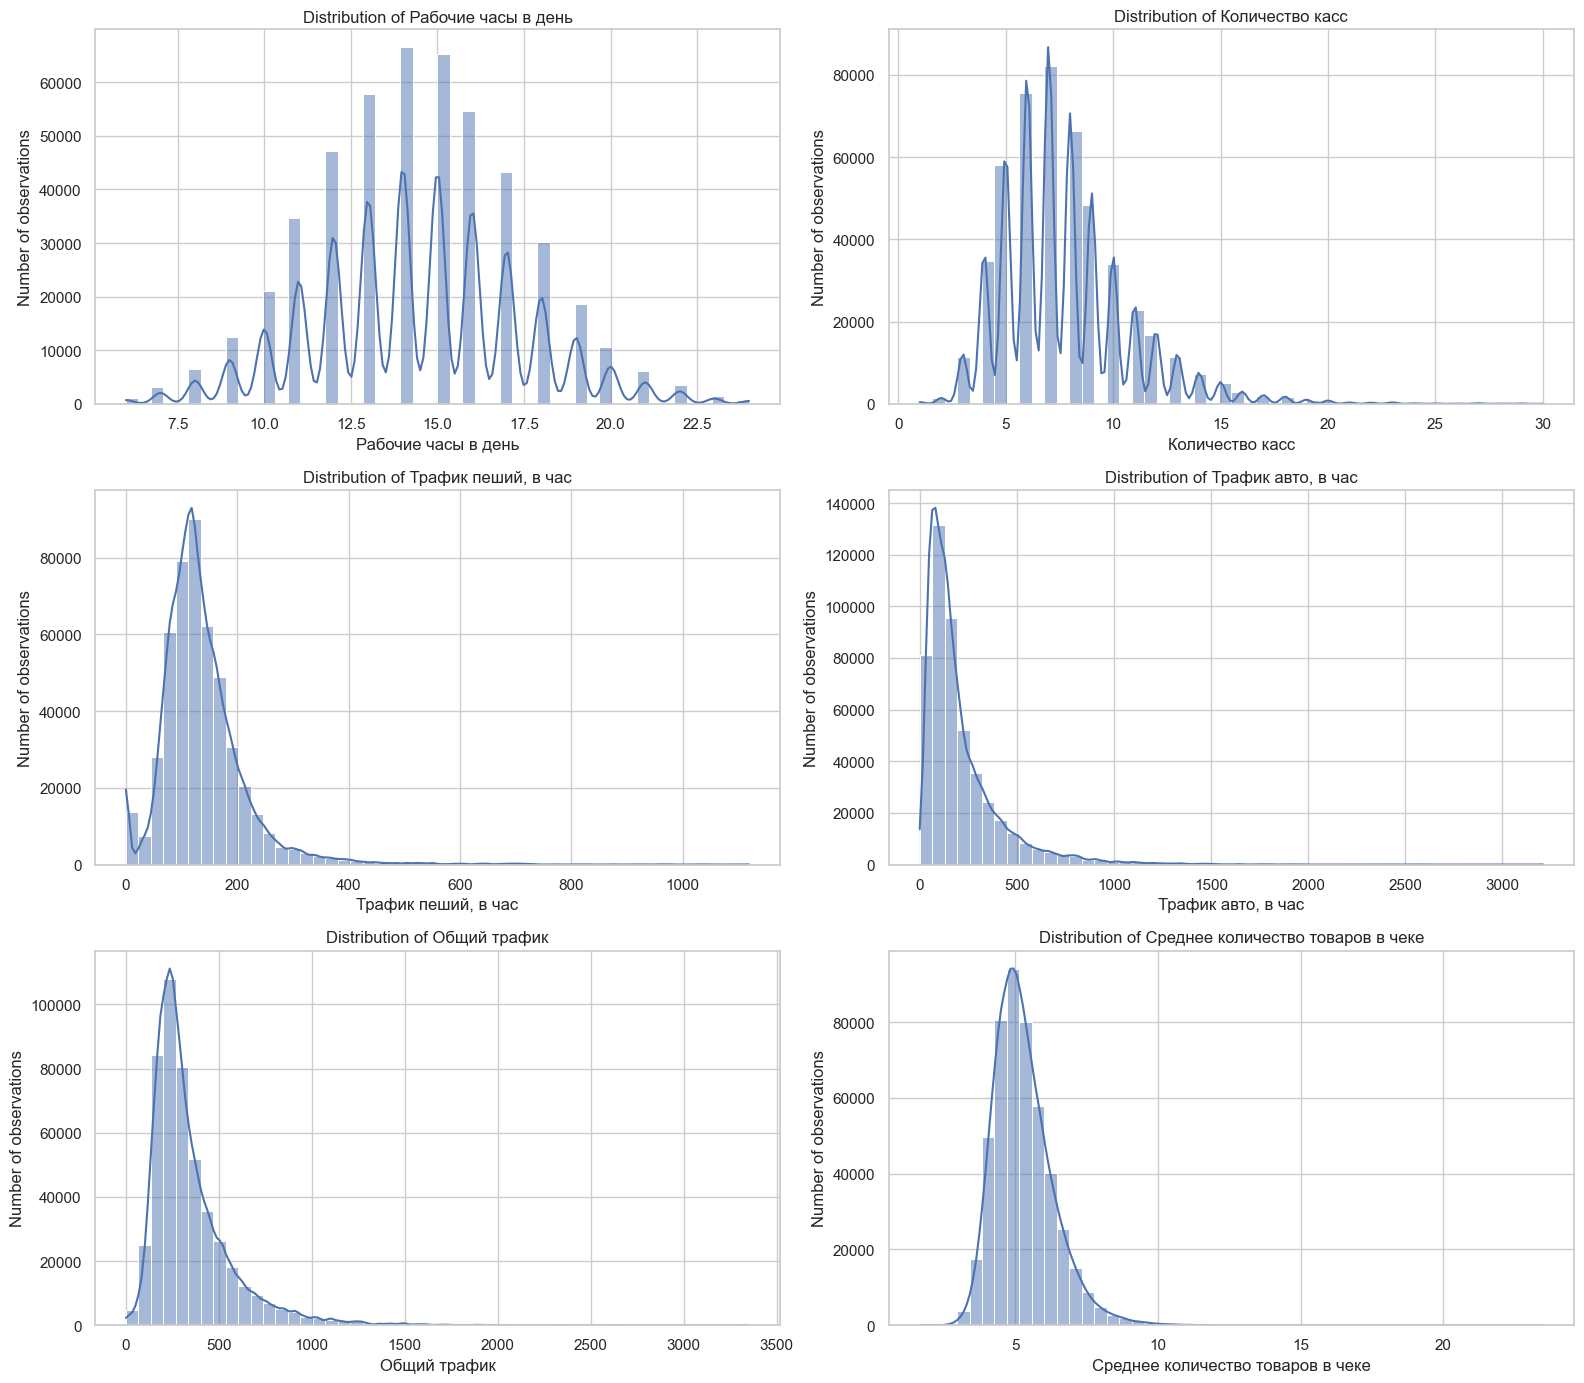

In [25]:
total_traffic_plot = clean["Трафик пеший, в час"] + clean["Трафик авто, в час"]
numeric_overview = pd.DataFrame({
    "Рабочие часы в день": clean["Рабочие часы в день"],
    "Количество касс": clean["Количество касс"],
    "Трафик пеший, в час": clean["Трафик пеший, в час"],
    "Трафик авто, в час": clean["Трафик авто, в час"],
    "Общий трафик": total_traffic_plot,
    "Среднее количество товаров в чеке": clean["Среднее количество товаров в чеке"],
})

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, col in zip(axes, numeric_overview.columns):
    sns.histplot(numeric_overview[col], bins=50, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of observations")

plt.tight_layout()
plt.show()


These histograms cover more than four numerical fields. They show that traffic and turnover-related variables are skewed, while working hours and cash registers are concentrated around typical store formats.


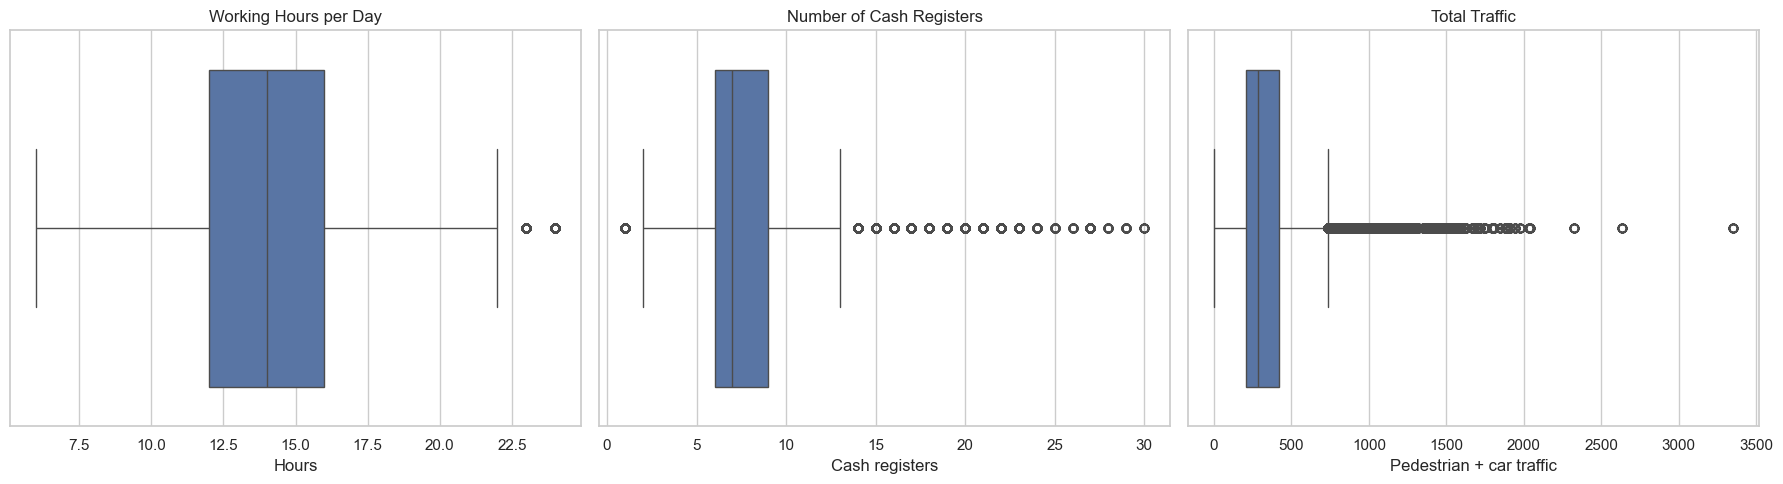

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=clean["Рабочие часы в день"], ax=axes[0])
axes[0].set_title("Working Hours per Day")
axes[0].set_xlabel("Hours")

sns.boxplot(x=clean["Количество касс"], ax=axes[1])
axes[1].set_title("Number of Cash Registers")
axes[1].set_xlabel("Cash registers")

sns.boxplot(x=total_traffic_plot, ax=axes[2])
axes[2].set_title("Total Traffic")
axes[2].set_xlabel("Pedestrian + car traffic")

plt.tight_layout()
plt.show()


The boxplots summarize the spread of operational variables after cleanup and imputation.


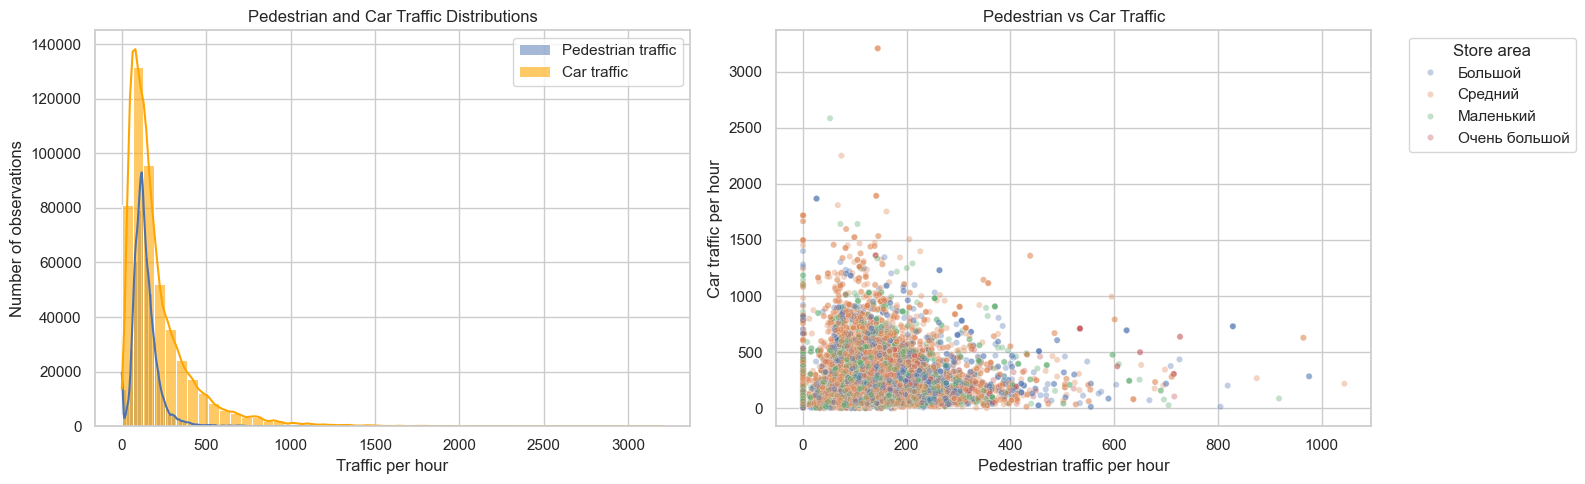

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(clean["Трафик пеший, в час"], bins=50, kde=True, ax=axes[0], label="Pedestrian traffic")
sns.histplot(clean["Трафик авто, в час"], bins=50, kde=True, ax=axes[0], color="orange", label="Car traffic", alpha=0.6)
axes[0].set_title("Pedestrian and Car Traffic Distributions")
axes[0].set_xlabel("Traffic per hour")
axes[0].set_ylabel("Number of observations")
axes[0].legend()

traffic_sample = clean.sample(n=min(20000, len(clean)), random_state=42)
sns.scatterplot(
    data=traffic_sample,
    x="Трафик пеший, в час",
    y="Трафик авто, в час",
    hue="Торговая площадь, категориальный",
    alpha=0.35,
    s=20,
    ax=axes[1]
)
axes[1].set_title("Pedestrian vs Car Traffic")
axes[1].set_xlabel("Pedestrian traffic per hour")
axes[1].set_ylabel("Car traffic per hour")
axes[1].legend(title="Store area", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


The traffic plots compare pedestrian and car traffic. The scatter plot uses a sample to keep the figure readable.


### 5.4 Regional and Anomaly Overview

The next plots summarize regional representation and the frequency of anomaly flags created during cleanup.


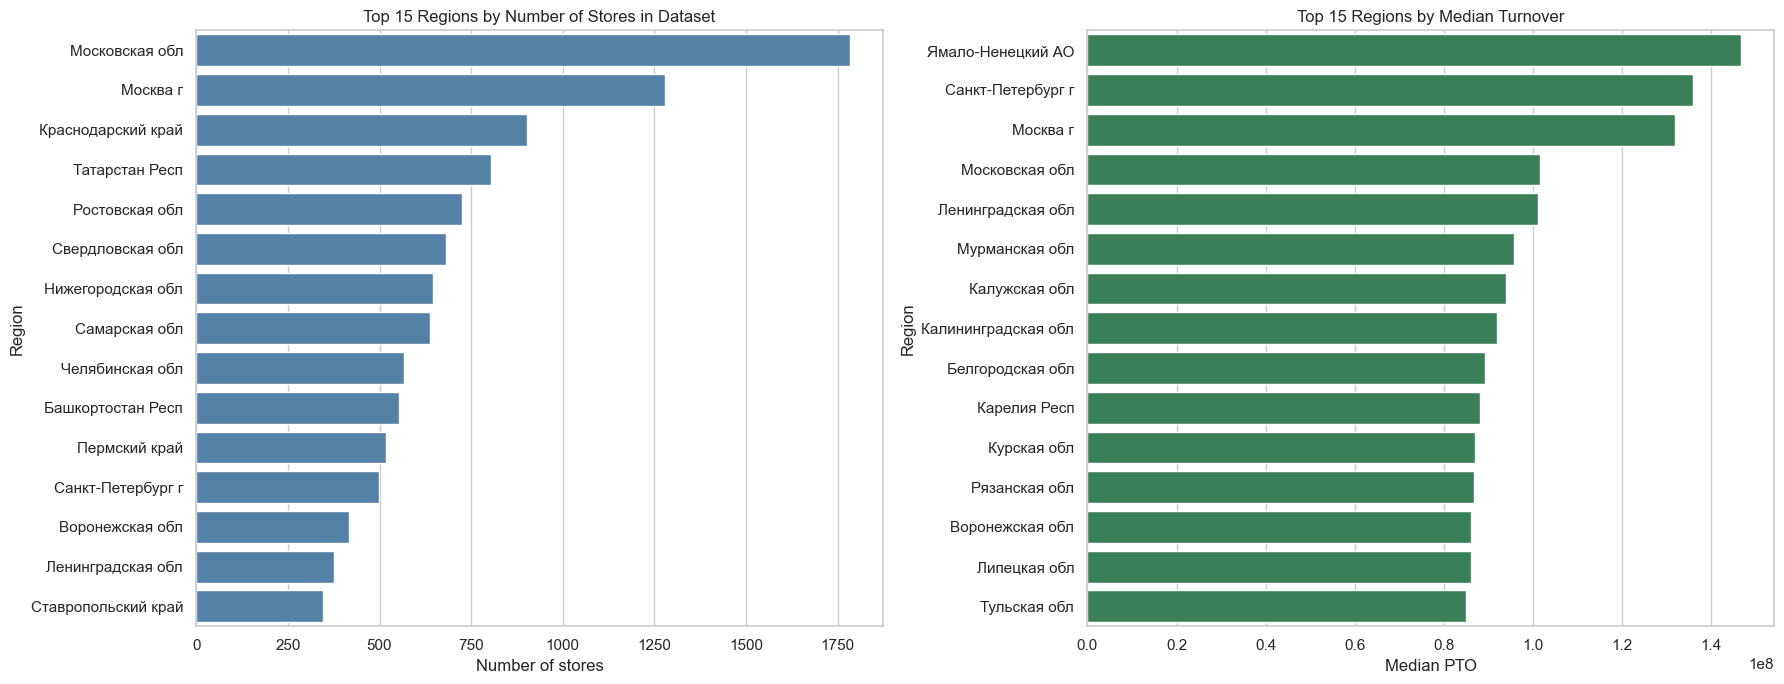

In [28]:
region_store_count = (
    clean.groupby("Регион")["new_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="stores")
)

region_median_rto = (
    clean.groupby("Регион")["РТО"]
    .median()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="median_RTO")
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=region_store_count, y="Регион", x="stores", ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 Regions by Number of Stores in Dataset")
axes[0].set_xlabel("Number of stores")
axes[0].set_ylabel("Region")

sns.barplot(data=region_median_rto, y="Регион", x="median_RTO", ax=axes[1], color="seagreen")
axes[1].set_title("Top 15 Regions by Median Turnover")
axes[1].set_xlabel("Median РТО")
axes[1].set_ylabel("Region")

plt.tight_layout()
plt.show()


Regional store counts describe the available dataset, not necessarily the exact real distribution of all Pyaterochka stores. Median turnover is used to compare typical store-month performance across regions.


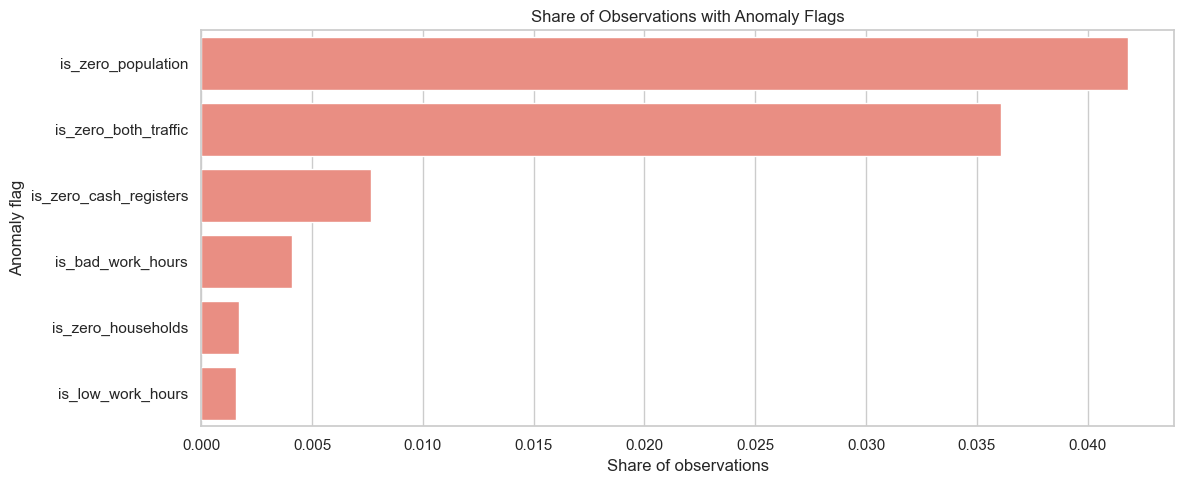

,flag,share
0,is_zero_population,0.041807
1,is_zero_both_traffic,0.036072
2,is_zero_cash_registers,0.007665
3,is_bad_work_hours,0.004074
4,is_zero_households,0.001715
5,is_low_work_hours,0.001554


In [29]:
flag_cols = [
    "is_bad_work_hours",
    "is_low_work_hours",
    "is_zero_population",
    "is_zero_households",
    "is_zero_both_traffic",
    "is_zero_cash_registers",
]

flag_summary = (
    clean[flag_cols]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "flag", 0: "share"})
)

plt.figure(figsize=(12, 5))
sns.barplot(data=flag_summary, x="share", y="flag", color="salmon")
plt.title("Share of Observations with Anomaly Flags")
plt.xlabel("Share of observations")
plt.ylabel("Anomaly flag")
plt.tight_layout()
plt.show()

flag_summary


The anomaly flags show that hidden data quality problems are not rare. These flags are kept because the fact that a value was corrected may itself be informative.


## 6. Detailed Overview

This section explores more detailed relationships between variables. It includes regional comparisons, grouped turnover distributions, correlations, scatter plots, and categorical interactions.


### 6.1 Regional Analysis Inside the Dataset

The dataset contains a large share of Pyaterochka stores, but we do not have official store counts by region inside the dataset. Therefore, regional store counts below describe the available dataset and should be interpreted carefully.


In [30]:
estimated_total_pyaterochka_stores_2023 = 21_308
stores_in_dataset = clean["new_id"].nunique()
approx_dataset_coverage = stores_in_dataset / estimated_total_pyaterochka_stores_2023

pd.DataFrame({
    "Metric": [
        "Stores in dataset",
        "Estimated total Pyaterochka stores in Russia, 2023",
        "Approximate national dataset coverage",
    ],
    "Value": [
        stores_in_dataset,
        estimated_total_pyaterochka_stores_2023,
        approx_dataset_coverage,
    ]
})


,Metric,Value
0,Stores in dataset,18657.000000
1,"Estimated total Pyaterochka stores in Russia, ...",21308.000000
2,Approximate national dataset coverage,0.875587


In [31]:
detailed = clean.assign(
    total_traffic_temp=clean["Трафик пеший, в час"] + clean["Трафик авто, в час"],
    log_RTO_temp=np.log1p(clean["РТО"]),
)

region_analysis = (
    detailed.groupby("Регион")
    .agg(
        stores_in_dataset=("new_id", "nunique"),
        observations=("new_id", "size"),
        total_RTO_in_dataset=("РТО", "sum"),
        mean_RTO=("РТО", "mean"),
        median_RTO=("РТО", "median"),
        median_population=("Численность населения", "median"),
        median_total_traffic=("total_traffic_temp", "median"),
        median_cash_registers=("Количество касс", "median"),
        big_store_share=("Торговая площадь, категориальный", lambda x: x.isin(["Большой", "Очень большой"]).mean()),
        alcohol_license_share=("Флаг алкогольной лицензии", "mean"),
        bad_population_share=("is_zero_population", "mean"),
        zero_traffic_share=("is_zero_both_traffic", "mean"),
    )
    .reset_index()
)

region_analysis["avg_monthly_RTO_per_store"] = (
    region_analysis["total_RTO_in_dataset"] / region_analysis["observations"]
)

region_analysis_filtered = region_analysis[region_analysis["stores_in_dataset"] >= 30].copy()
region_analysis_filtered.sort_values("total_RTO_in_dataset", ascending=False).head(15)


,Регион,stores_in_dataset,observations,total_RTO_in_dataset,mean_RTO,median_RTO,median_population,median_total_traffic,median_cash_registers,big_store_share,alcohol_license_share,bad_population_share,zero_traffic_share,avg_monthly_RTO_per_store
33,Московская обл,1784,46384,5.326202e+12,1.148284e+08,1.015501e+08,68498.0,272.0,8.0,0.312220,0.924327,0.092489,0.077915,1.148284e+08
32,Москва г,1278,33228,4.851874e+12,1.460176e+08,1.319528e+08,12285198.0,333.5,10.0,0.409233,0.888889,0.028169,0.000000,1.460176e+08
47,Санкт-Петербург г,498,12948,1.979380e+12,1.528715e+08,1.359678e+08,5495826.5,356.5,10.0,0.506024,0.927711,0.000000,0.000000,1.528715e+08
24,Краснодарский край,902,23452,1.823781e+12,7.776654e+07,6.705229e+07,72388.0,284.0,7.0,0.110865,0.951220,0.032151,0.017738,7.776654e+07
54,Татарстан Респ,803,20878,1.748157e+12,8.373201e+07,7.519719e+07,563567.0,282.0,8.0,0.271482,0.930262,0.013699,0.021171,8.373201e+07
35,Нижегородская обл,645,16770,1.371396e+12,8.177672e+07,7.359430e+07,188425.0,254.0,7.0,0.263566,0.944186,0.049612,0.049612,8.177672e+07
44,Ростовская обл,726,18876,1.367152e+12,7.242806e+07,6.603443e+07,164219.0,317.5,7.0,0.111570,0.920110,0.026171,0.013774,7.242806e+07
49,Свердловская обл,682,17732,1.364528e+12,7.695287e+07,6.881156e+07,114015.0,255.0,7.0,0.233138,0.941349,0.068915,0.049853,7.695287e+07
46,Самарская обл,639,16614,1.213388e+12,7.303407e+07,6.557787e+07,763387.0,295.0,7.0,0.259781,0.934272,0.015649,0.020344,7.303407e+07
28,Ленинградская обл,375,9750,1.123697e+12,1.152509e+08,1.011160e+08,17167.5,220.0,8.0,0.296000,0.930667,0.072000,0.141333,1.152509e+08


This table compares regions by total turnover inside the dataset, median turnover, store count, traffic, store format, and anomaly shares. Regions with fewer than 30 stores are excluded from the following plots to reduce noise.


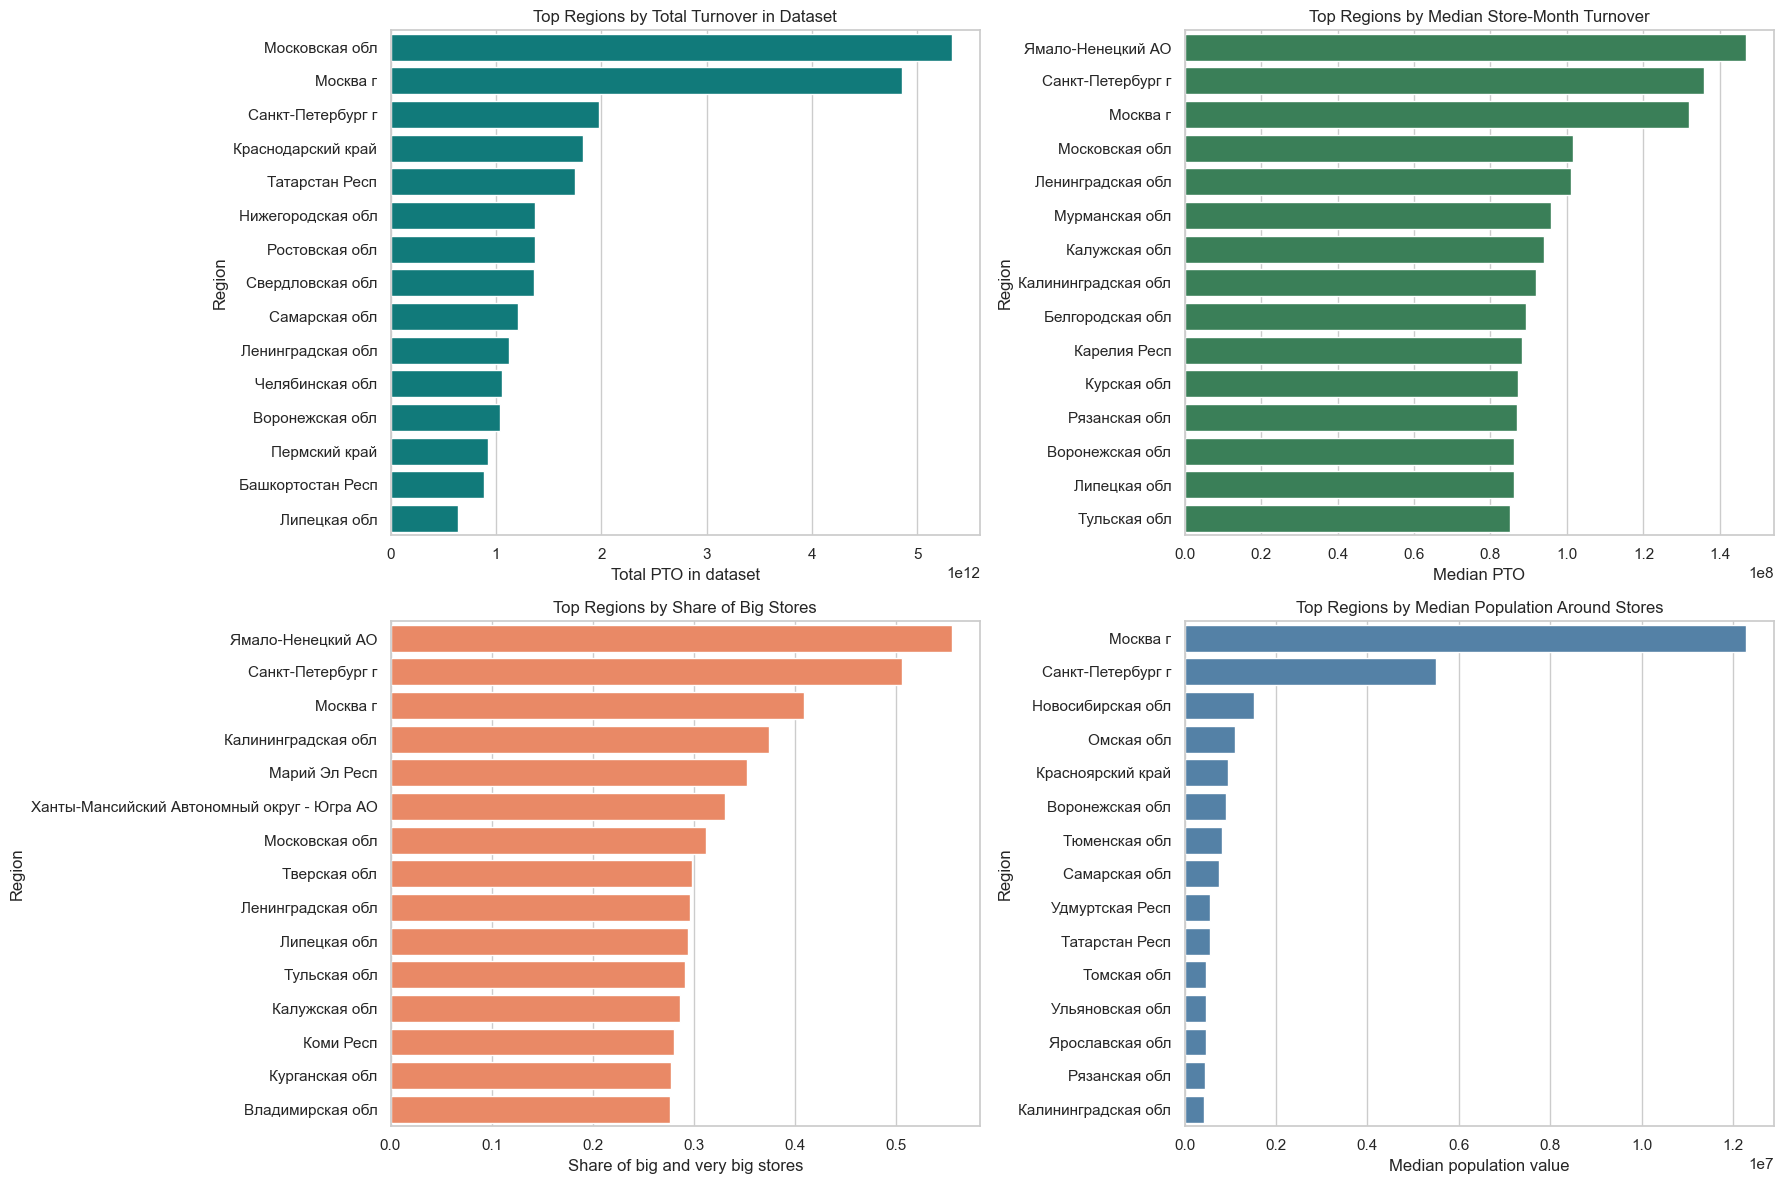

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top_total = region_analysis_filtered.sort_values("total_RTO_in_dataset", ascending=False).head(15)
sns.barplot(data=top_total, y="Регион", x="total_RTO_in_dataset", ax=axes[0, 0], color="darkcyan")
axes[0, 0].set_title("Top Regions by Total Turnover in Dataset")
axes[0, 0].set_xlabel("Total РТО in dataset")
axes[0, 0].set_ylabel("Region")

top_median = region_analysis_filtered.sort_values("median_RTO", ascending=False).head(15)
sns.barplot(data=top_median, y="Регион", x="median_RTO", ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("Top Regions by Median Store-Month Turnover")
axes[0, 1].set_xlabel("Median РТО")
axes[0, 1].set_ylabel("Region")

top_big_share = region_analysis_filtered.sort_values("big_store_share", ascending=False).head(15)
sns.barplot(data=top_big_share, y="Регион", x="big_store_share", ax=axes[1, 0], color="coral")
axes[1, 0].set_title("Top Regions by Share of Big Stores")
axes[1, 0].set_xlabel("Share of big and very big stores")
axes[1, 0].set_ylabel("Region")

top_population = region_analysis_filtered.sort_values("median_population", ascending=False).head(15)
sns.barplot(data=top_population, y="Регион", x="median_population", ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Top Regions by Median Population Around Stores")
axes[1, 1].set_xlabel("Median population value")
axes[1, 1].set_ylabel("Region")

plt.tight_layout()
plt.show()


The four plots compare regions from different angles. Total turnover depends strongly on how many stores are present in the dataset, so it should be read together with median turnover and store count.


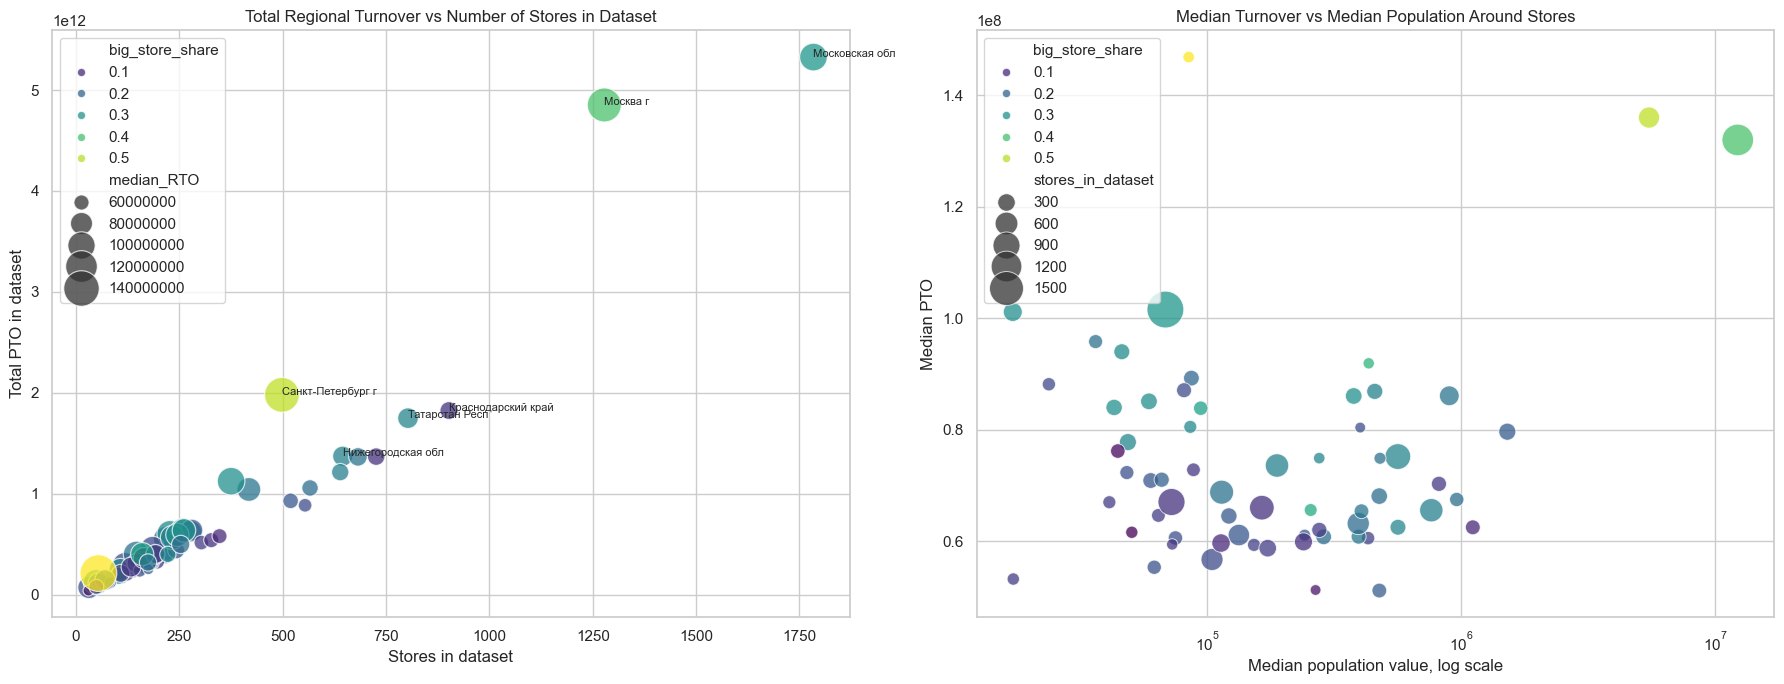

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=region_analysis_filtered,
    x="stores_in_dataset",
    y="total_RTO_in_dataset",
    size="median_RTO",
    hue="big_store_share",
    sizes=(60, 700),
    alpha=0.75,
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Total Regional Turnover vs Number of Stores in Dataset")
axes[0].set_xlabel("Stores in dataset")
axes[0].set_ylabel("Total РТО in dataset")

for _, row in region_analysis_filtered.nlargest(6, "total_RTO_in_dataset").iterrows():
    axes[0].annotate(row["Регион"], (row["stores_in_dataset"], row["total_RTO_in_dataset"]), fontsize=8)

sns.scatterplot(
    data=region_analysis_filtered,
    x="median_population",
    y="median_RTO",
    size="stores_in_dataset",
    hue="big_store_share",
    sizes=(60, 700),
    alpha=0.75,
    palette="viridis",
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("Median Turnover vs Median Population Around Stores")
axes[1].set_xlabel("Median population value, log scale")
axes[1].set_ylabel("Median РТО")

plt.tight_layout()
plt.show()


The scatter plots show that total regional turnover is closely related to the number of stores in the dataset. The second plot compares median turnover with population values around stores.


### 6.2 Turnover Distribution in the Largest Regions

Aggregate regional statistics can hide variation between stores. The following boxplot compares store-month turnover distributions in the largest regions.


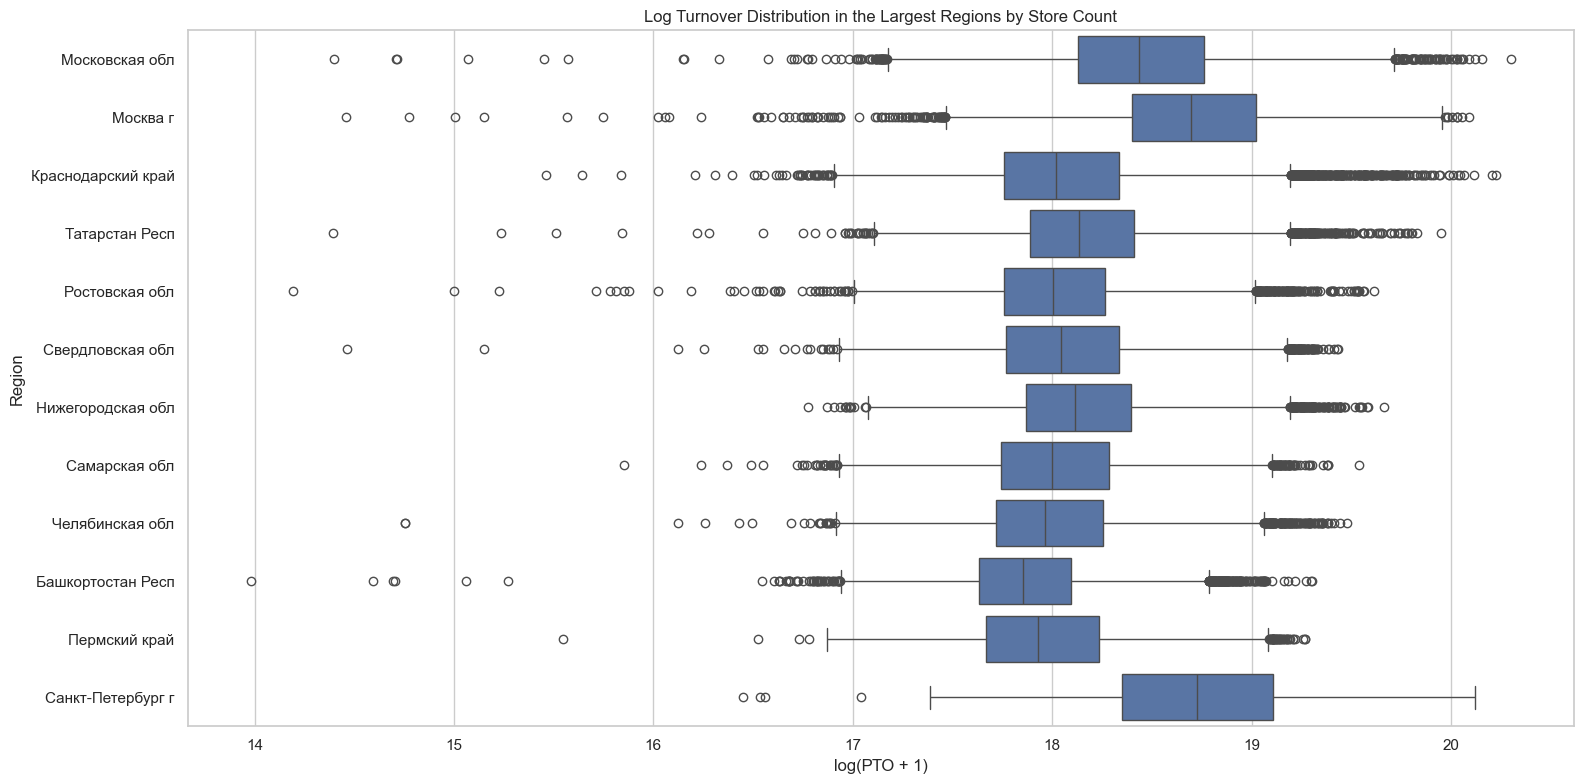

In [34]:
top_regions_by_stores = (
    region_analysis
    .sort_values("stores_in_dataset", ascending=False)
    .head(12)["Регион"]
)

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=detailed[detailed["Регион"].isin(top_regions_by_stores)],
    y="Регион",
    x="log_RTO_temp",
    order=top_regions_by_stores,
)
plt.title("Log Turnover Distribution in the Largest Regions by Store Count")
plt.xlabel("log(РТО + 1)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


This plot compares not only typical values, but also variation and outliers inside each large region.


### 6.3 Correlation and Feature Relationships

A correlation matrix and scatter plots help identify relationships between numerical features and turnover.


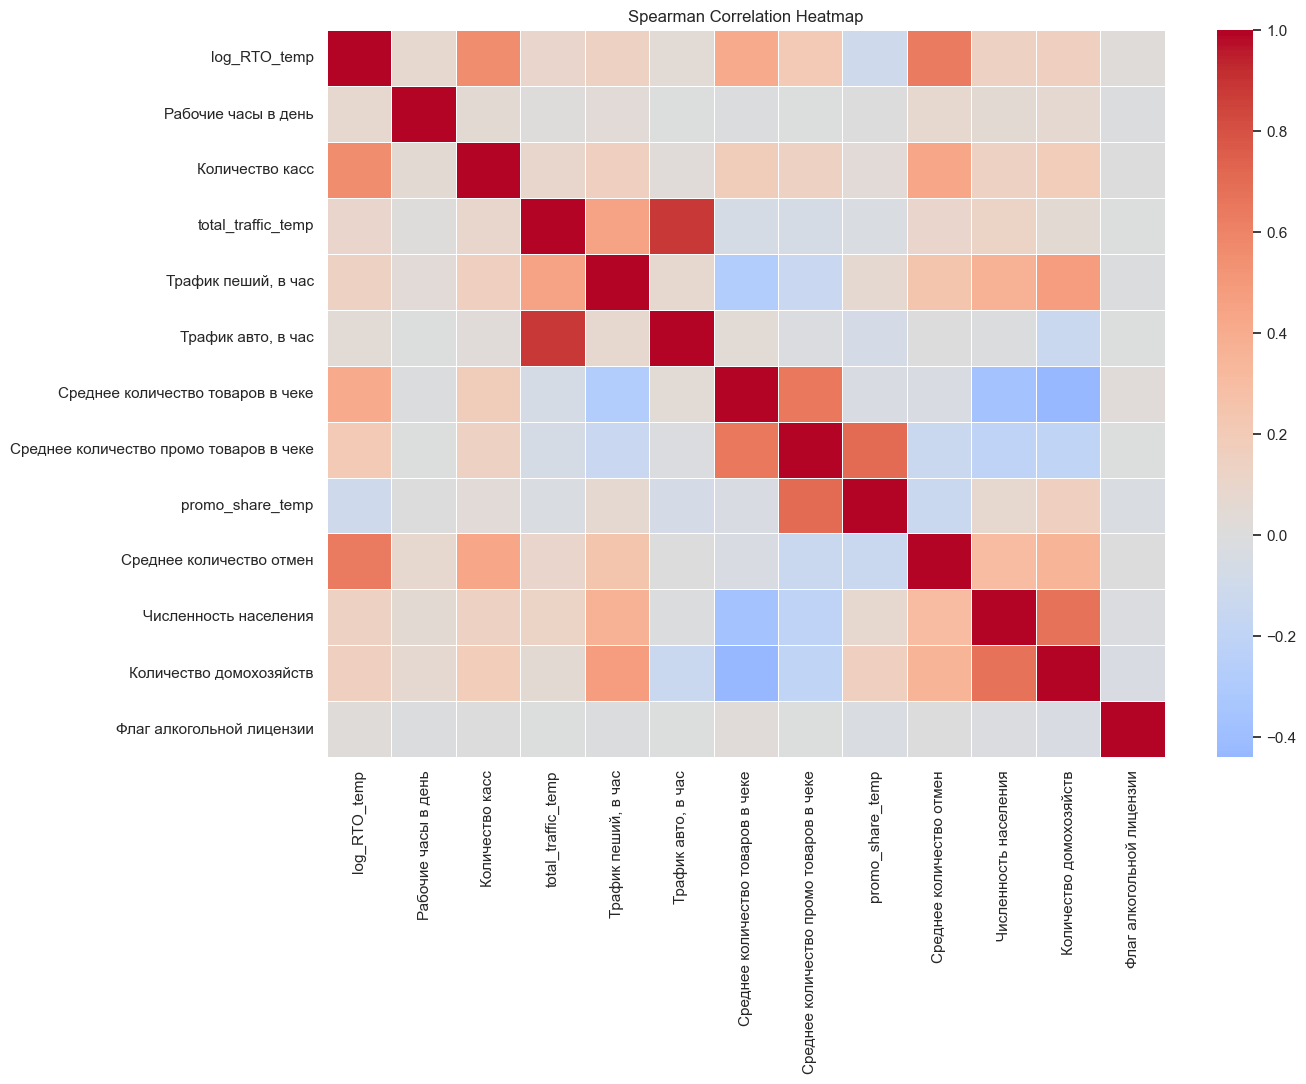

log_RTO_temp                               1.000000
Среднее количество отмен                   0.638716
Количество касс                            0.560815
Среднее количество товаров в чеке          0.409167
Среднее количество промо товаров в чеке    0.202379
Количество домохозяйств                    0.158582
Трафик пеший, в час                        0.143691
Численность населения                      0.139531
total_traffic_temp                         0.099433
Рабочие часы в день                        0.075893
Трафик авто, в час                         0.044310
Флаг алкогольной лицензии                  0.019459
promo_share_temp                          -0.105543
Name: log_RTO_temp, dtype: float64

In [35]:
corr_data = clean.assign(
    log_RTO_temp=np.log1p(clean["РТО"]),
    total_traffic_temp=clean["Трафик пеший, в час"] + clean["Трафик авто, в час"],
    promo_share_temp=np.where(
        clean["Среднее количество товаров в чеке"] > 0,
        clean["Среднее количество промо товаров в чеке"] / clean["Среднее количество товаров в чеке"],
        np.nan,
    ),
)

corr_cols = [
    "log_RTO_temp",
    "Рабочие часы в день",
    "Количество касс",
    "total_traffic_temp",
    "Трафик пеший, в час",
    "Трафик авто, в час",
    "Среднее количество товаров в чеке",
    "Среднее количество промо товаров в чеке",
    "promo_share_temp",
    "Среднее количество отмен",
    "Численность населения",
    "Количество домохозяйств",
    "Флаг алкогольной лицензии",
]

corr_matrix = corr_data[corr_cols].corr(method="spearman")

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()

corr_matrix["log_RTO_temp"].sort_values(ascending=False)


Spearman correlation is used because many variables are skewed. The sorted correlations show which numerical fields are most strongly associated with logarithmic turnover.


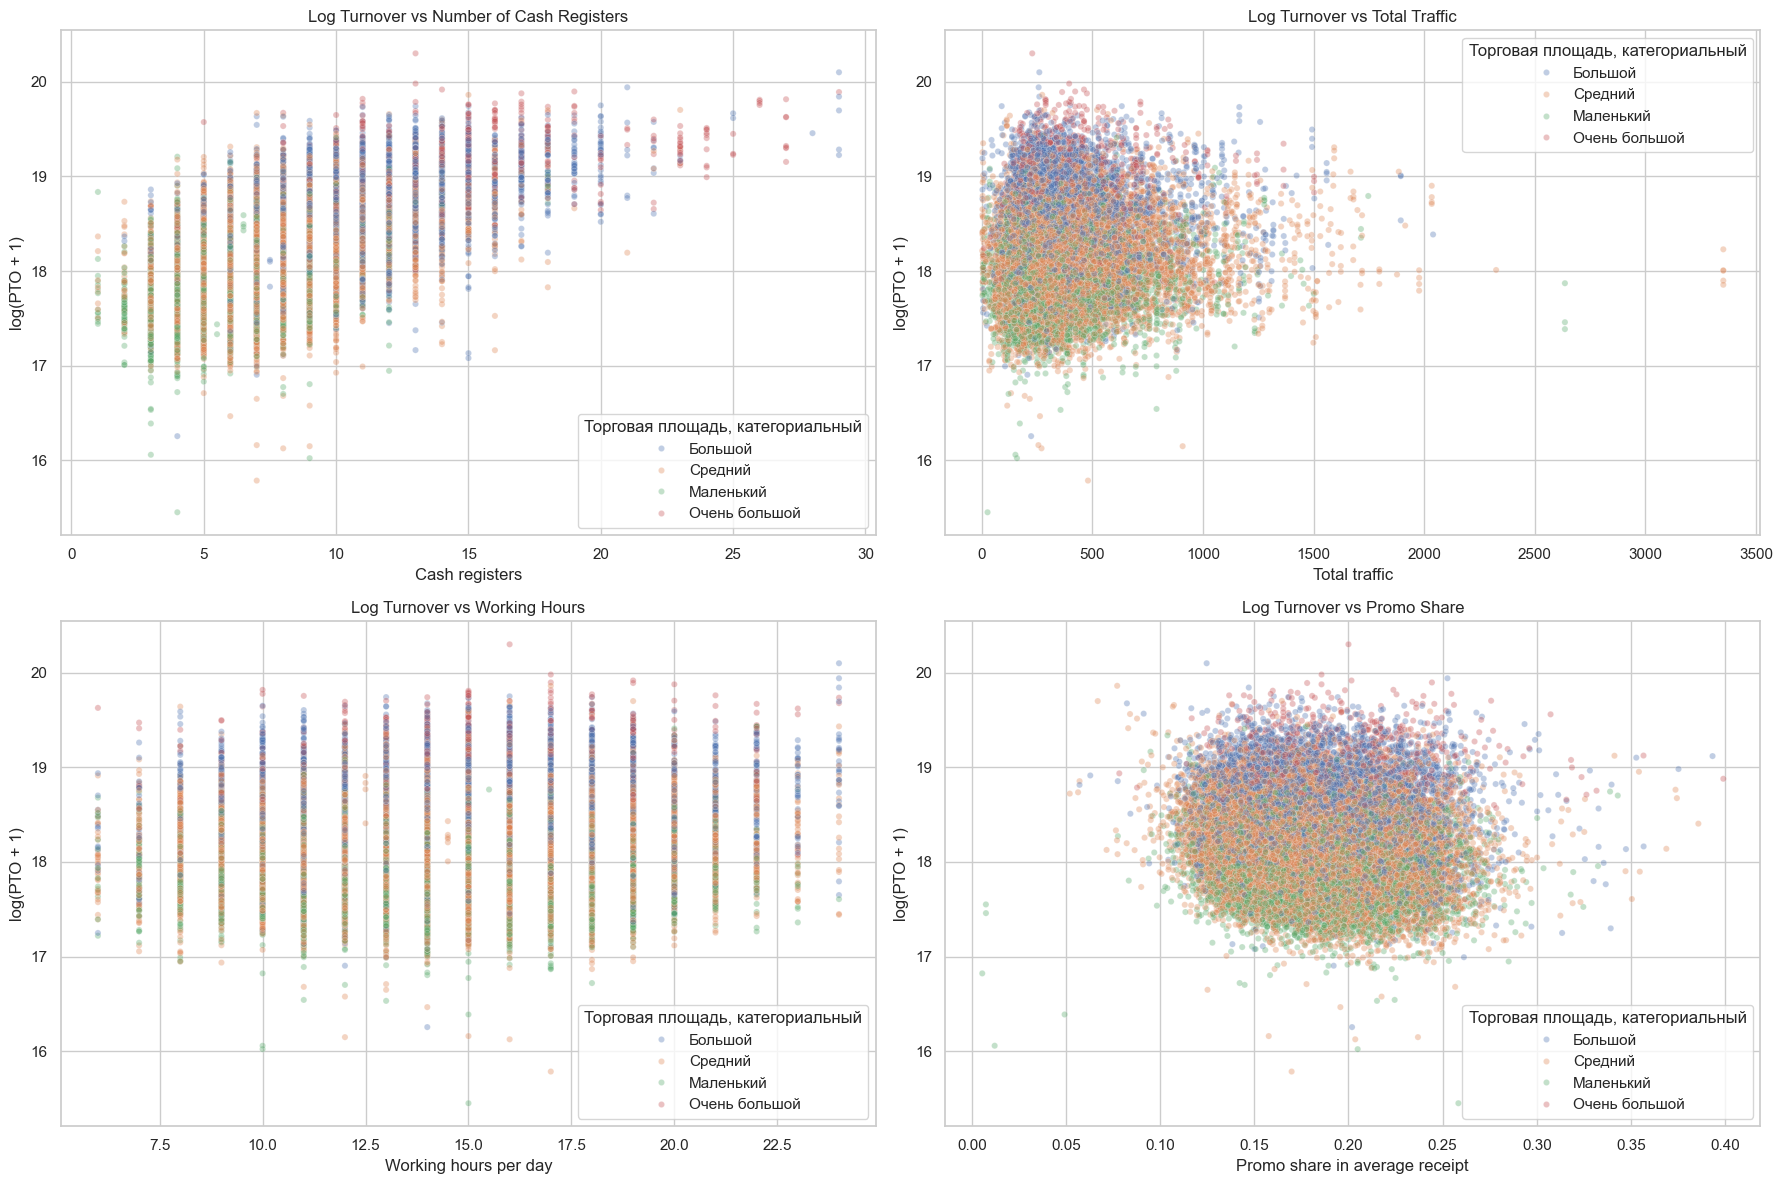

In [36]:
plot_sample = corr_data.sample(n=min(30000, len(corr_data)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.scatterplot(data=plot_sample, x="Количество касс", y="log_RTO_temp", hue="Торговая площадь, категориальный", alpha=0.35, s=20, ax=axes[0, 0])
axes[0, 0].set_title("Log Turnover vs Number of Cash Registers")
axes[0, 0].set_xlabel("Cash registers")
axes[0, 0].set_ylabel("log(РТО + 1)")

sns.scatterplot(data=plot_sample, x="total_traffic_temp", y="log_RTO_temp", hue="Торговая площадь, категориальный", alpha=0.35, s=20, ax=axes[0, 1])
axes[0, 1].set_title("Log Turnover vs Total Traffic")
axes[0, 1].set_xlabel("Total traffic")
axes[0, 1].set_ylabel("log(РТО + 1)")

sns.scatterplot(data=plot_sample, x="Рабочие часы в день", y="log_RTO_temp", hue="Торговая площадь, категориальный", alpha=0.35, s=20, ax=axes[1, 0])
axes[1, 0].set_title("Log Turnover vs Working Hours")
axes[1, 0].set_xlabel("Working hours per day")
axes[1, 0].set_ylabel("log(РТО + 1)")

sns.scatterplot(data=plot_sample, x="promo_share_temp", y="log_RTO_temp", hue="Торговая площадь, категориальный", alpha=0.35, s=20, ax=axes[1, 1])
axes[1, 1].set_title("Log Turnover vs Promo Share")
axes[1, 1].set_xlabel("Promo share in average receipt")
axes[1, 1].set_ylabel("log(РТО + 1)")

plt.tight_layout()
plt.show()


The scatter plots compare turnover with capacity, traffic, working schedule, and receipt structure. Store area is used as color to show whether these relationships differ by store format.


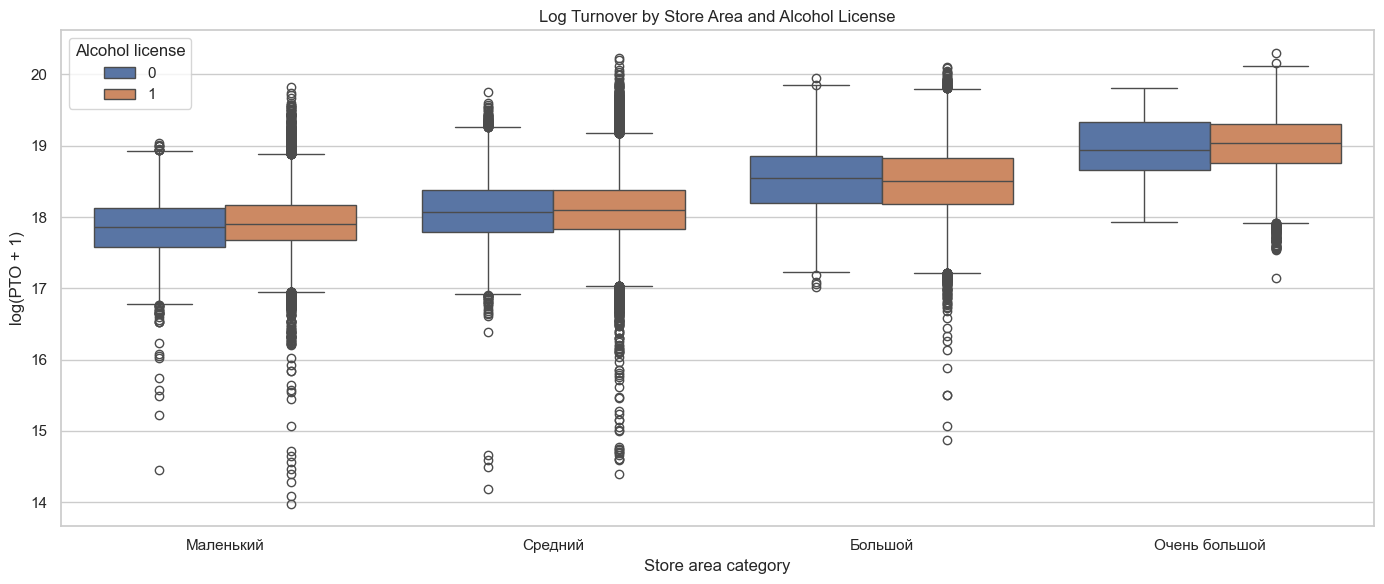

In [37]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=corr_data,
    x="Торговая площадь, категориальный",
    y="log_RTO_temp",
    hue="Флаг алкогольной лицензии",
    order=corr_data.groupby("Торговая площадь, категориальный")["log_RTO_temp"].median().sort_values().index,
)
plt.title("Log Turnover by Store Area and Alcohol License")
plt.xlabel("Store area category")
plt.ylabel("log(РТО + 1)")
plt.legend(title="Alcohol license")
plt.tight_layout()
plt.show()


This comparison combines two categorical features: store area and alcohol license. It helps evaluate whether turnover differences are visible across store formats and license groups.


## 7. Data Transformation

This section creates new derived columns that are used in the hypothesis checks and final interpretation. The original columns are not deleted.


In [38]:
clean["total_traffic"] = clean["Трафик пеший, в час"] + clean["Трафик авто, в час"]

clean["promo_share"] = np.where(
    clean["Среднее количество товаров в чеке"] > 0,
    clean["Среднее количество промо товаров в чеке"] / clean["Среднее количество товаров в чеке"],
    np.nan,
)

clean["rto_per_cash_register"] = np.where(
    clean["Количество касс"] > 0,
    clean["РТО"] / clean["Количество касс"],
    np.nan,
)

clean["log_RTO"] = np.log1p(clean["РТО"])


The new columns have the following meanings:

- `total_traffic`: pedestrian traffic plus car traffic. It summarizes local traffic around the store.
- `promo_share`: the share of promotional items in the average receipt. It describes receipt structure.
- `rto_per_cash_register`: monthly turnover divided by the number of cash registers. It is a simple capacity-normalized turnover metric.
- `log_RTO`: logarithmic turnover used for skewed distributions and visualizations.


In [39]:
transformed_columns = ["total_traffic", "promo_share", "rto_per_cash_register", "log_RTO"]
clean[transformed_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
total_traffic,485082.0,3.454940e+02,2.180650e+02,1.000000,2.080000e+02,2.840000e+02,4.190000e+02,3.352000e+03
promo_share,485082.0,1.817505e-01,3.544499e-02,-0.000000,1.553885e-01,1.779242e-01,2.059406e-01,5.580286e-01
rto_per_cash_register,485082.0,1.181601e+07,5.228406e+06,207834.787143,8.348257e+06,1.081961e+07,1.414035e+07,1.673626e+08
log_RTO,485082.0,1.818061e+01,4.722801e-01,13.980276,1.784572e+01,1.813581e+01,1.847676e+01,2.030125e+01


The descriptive table confirms that the new columns were created successfully and gives their basic scale.


In [40]:
inflation_rates = {
    2023: 0.0742,
    2024: 0.0952,
    2025: 0.0000,
}

inflation_multiplier_to_2025 = {
    2023: (1 + inflation_rates[2023]) * (1 + inflation_rates[2024]),
    2024: (1 + inflation_rates[2024]),
    2025: 1.0,
}

clean["inflation_multiplier_to_2025"] = clean["Год"].map(inflation_multiplier_to_2025)
clean["RTO_2025_prices"] = clean["РТО"] * clean["inflation_multiplier_to_2025"]
clean["log_RTO_2025_prices"] = np.log1p(clean["RTO_2025_prices"])

clean[["Год", "РТО", "inflation_multiplier_to_2025", "RTO_2025_prices"]].head()


,Год,РТО,inflation_multiplier_to_2025,RTO_2025_prices
0,2024,75147744.85,1.095200,8.230181e+07
1,2023,74914754.22,1.176464,8.813450e+07
2,2025,87125506.92,1.000000,8.712551e+07
3,2025,82659801.63,1.000000,8.265980e+07
4,2024,74209339.11,1.095200,8.127407e+07


`RTO_2025_prices` is an approximate inflation-adjusted turnover measure. 2025 is used as the base year, so its multiplier is 1.0 — this does not mean zero inflation in 2025, it means 2025 prices are the reference point. It is useful for comparing monetary values across years, but it should not be interpreted as an official financial recalculation.

In [41]:
clean[[
    "total_traffic",
    "promo_share",
    "rto_per_cash_register",
    "log_RTO",
    "RTO_2025_prices",
    "log_RTO_2025_prices",
]].isna().sum()


total_traffic            0
promo_share              0
rto_per_cash_register    0
log_RTO                  0
RTO_2025_prices          0
log_RTO_2025_prices      0
dtype: int64

The final check confirms that the transformed columns do not introduce missing values.


## 8. Hypothesis Check

This section tests two hypotheses. The goal is to evaluate whether the patterns in the dataset support the hypotheses.


### 8.1 Hypothesis 1: Same-Store Turnover Growth Is Higher Than Official Inflation

**Hypothesis:** same-store turnover growth in grocery retail is higher than official inflation.

This hypothesis is interesting because `РТО` is a monetary variable observed over several years. We compare January 2024 with January 2023 and January 2025 with January 2024 for the same stores. January is used because it is available for all three years.

Important limitation: `РТО` is not a price index. Its growth can be caused by price inflation, more purchases, product mix, promotions, or customer behavior.


In [42]:
official_inflation = {
    "Jan 2023 -> Jan 2024": 0.0742,
    "Jan 2024 -> Jan 2025": 0.0952,
}

january_rto = (
    clean[(clean["Месяц"] == 1) & (clean["Год"].isin([2023, 2024, 2025]))]
    .pivot(index="new_id", columns="Год", values="РТО")
    .dropna(subset=[2023, 2024, 2025])
)

january_rto["growth_2024_vs_2023"] = january_rto[2024] / january_rto[2023] - 1
january_rto["growth_2025_vs_2024"] = january_rto[2025] / january_rto[2024] - 1

inflation_comparison = pd.DataFrame({
    "period": ["Jan 2023 -> Jan 2024", "Jan 2024 -> Jan 2025"],
    "official_inflation": [
        official_inflation["Jan 2023 -> Jan 2024"],
        official_inflation["Jan 2024 -> Jan 2025"],
    ],
    "median_same_store_RTO_growth": [
        january_rto["growth_2024_vs_2023"].median(),
        january_rto["growth_2025_vs_2024"].median(),
    ],
    "mean_same_store_RTO_growth": [
        january_rto["growth_2024_vs_2023"].mean(),
        january_rto["growth_2025_vs_2024"].mean(),
    ],
    "share_of_stores_above_official_inflation": [
        (january_rto["growth_2024_vs_2023"] > official_inflation["Jan 2023 -> Jan 2024"]).mean(),
        (january_rto["growth_2025_vs_2024"] > official_inflation["Jan 2024 -> Jan 2025"]).mean(),
    ],
})

inflation_comparison["median_growth_minus_official_inflation"] = (
    inflation_comparison["median_same_store_RTO_growth"] - inflation_comparison["official_inflation"]
)

inflation_comparison


,period,official_inflation,median_same_store_RTO_growth,mean_same_store_RTO_growth,share_of_stores_above_official_inflation,median_growth_minus_official_inflation
0,Jan 2023 -> Jan 2024,0.0742,0.131732,0.195598,0.695825,0.057532
1,Jan 2024 -> Jan 2025,0.0952,0.142178,0.154290,0.660503,0.046978


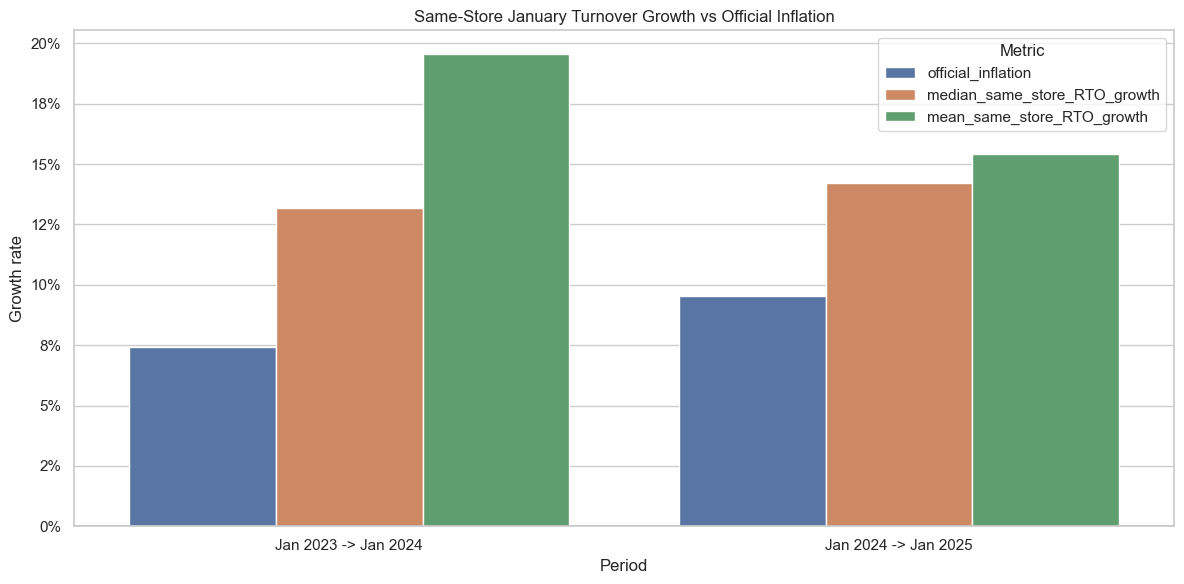

In [43]:
inflation_plot_data = inflation_comparison.melt(
    id_vars="period",
    value_vars=["official_inflation", "median_same_store_RTO_growth", "mean_same_store_RTO_growth"],
    var_name="metric",
    value_name="growth_rate",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=inflation_plot_data, x="period", y="growth_rate", hue="metric")
plt.axhline(0, color="black", linewidth=1)
plt.title("Same-Store January Turnover Growth vs Official Inflation")
plt.xlabel("Period")
plt.ylabel("Growth rate")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


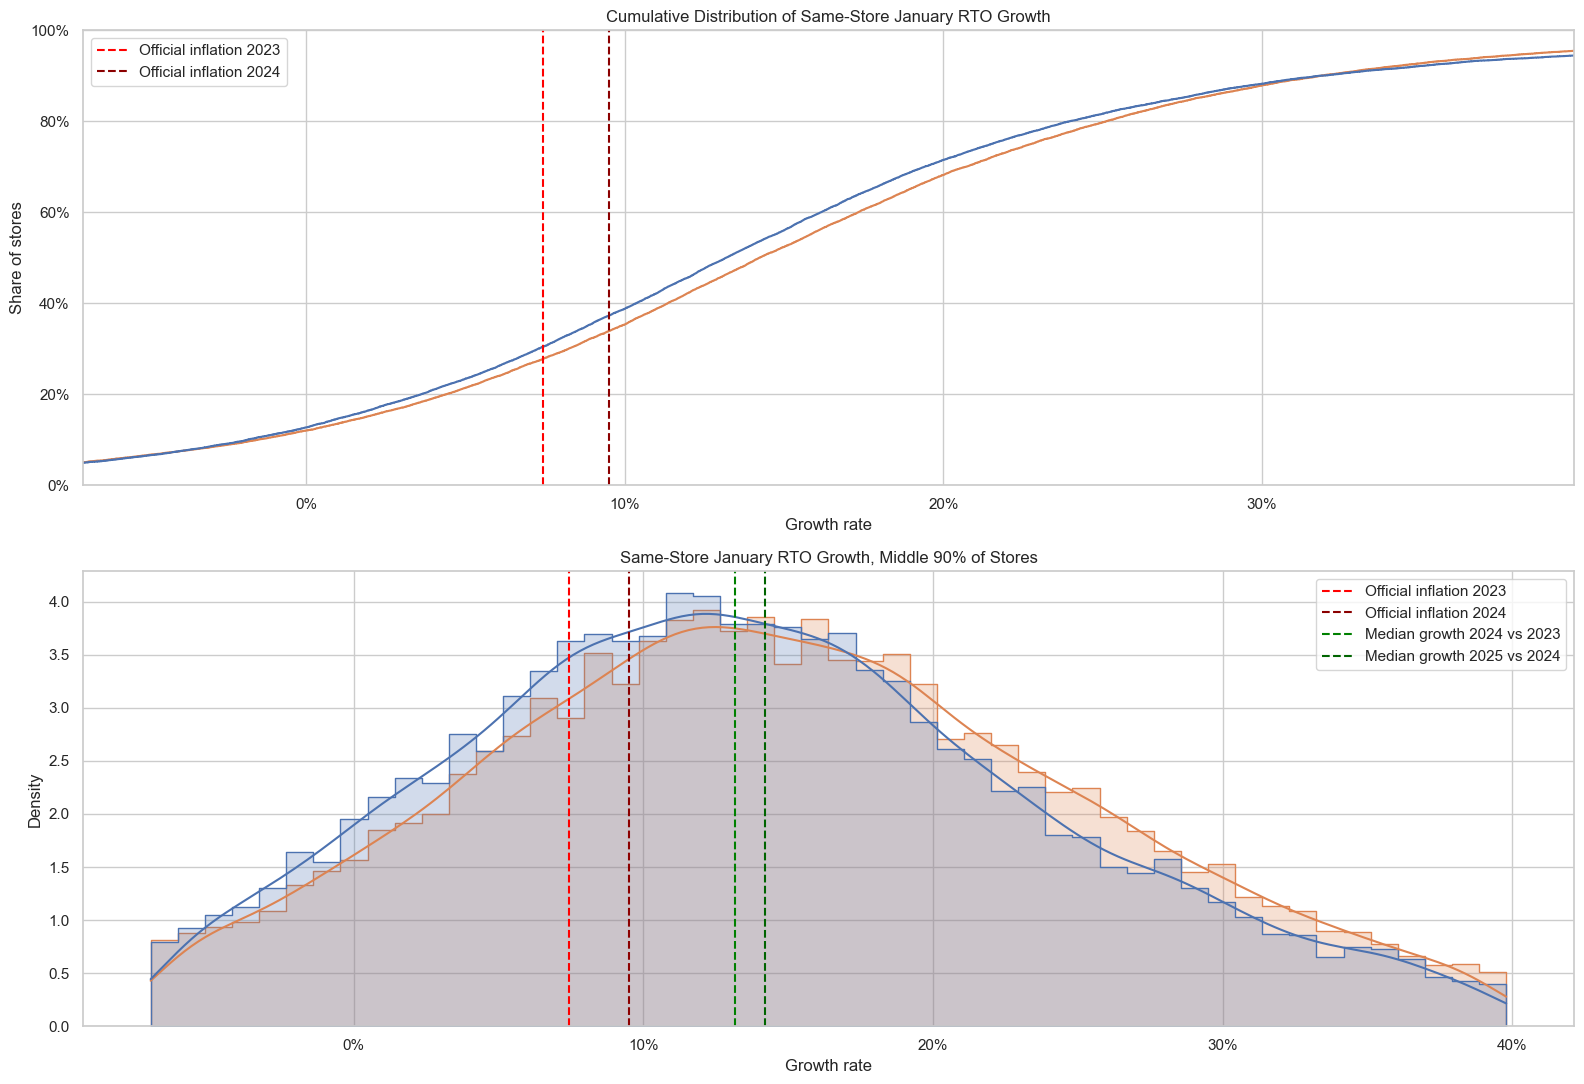

In [44]:
growth_2024 = january_rto["growth_2024_vs_2023"]
growth_2025 = january_rto["growth_2025_vs_2024"]

growth_long = pd.DataFrame({
    "Jan 2024 vs Jan 2023": growth_2024,
    "Jan 2025 vs Jan 2024": growth_2025,
}).melt(var_name="period", value_name="growth_rate")

x_min = growth_long["growth_rate"].quantile(0.05)
x_max = growth_long["growth_rate"].quantile(0.95)

fig, axes = plt.subplots(2, 1, figsize=(16, 11))

sns.ecdfplot(data=growth_long, x="growth_rate", hue="period", ax=axes[0])
axes[0].axvline(official_inflation["Jan 2023 -> Jan 2024"], color="red", linestyle="--", label="Official inflation 2023")
axes[0].axvline(official_inflation["Jan 2024 -> Jan 2025"], color="darkred", linestyle="--", label="Official inflation 2024")
axes[0].set_xlim(x_min, x_max)
axes[0].set_title("Cumulative Distribution of Same-Store January RTO Growth")
axes[0].set_xlabel("Growth rate")
axes[0].set_ylabel("Share of stores")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].legend()

sns.histplot(
    data=growth_long[(growth_long["growth_rate"] >= x_min) & (growth_long["growth_rate"] <= x_max)],
    x="growth_rate",
    hue="period",
    bins=50,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].axvline(official_inflation["Jan 2023 -> Jan 2024"], color="red", linestyle="--", label="Official inflation 2023")
axes[1].axvline(official_inflation["Jan 2024 -> Jan 2025"], color="darkred", linestyle="--", label="Official inflation 2024")
axes[1].axvline(growth_2024.median(), color="green", linestyle="--", label="Median growth 2024 vs 2023")
axes[1].axvline(growth_2025.median(), color="darkgreen", linestyle="--", label="Median growth 2025 vs 2024")
axes[1].set_title("Same-Store January RTO Growth, Middle 90% of Stores")
axes[1].set_xlabel("Growth rate")
axes[1].set_ylabel("Density")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].legend()

plt.tight_layout()
plt.show()


The hypothesis is partially supported. Median same-store turnover growth is higher than the official inflation benchmark in both tested periods, and most stores are above the official benchmark. However, this does not directly prove food price inflation because the dataset does not contain product-level prices or average receipt value.


#### Additional Check for Hypothesis 1

To avoid overclaiming, we compare turnover growth with operational features. If turnover grows much faster than traffic, working hours, cash registers, and the number of items in a receipt, then growth in the monetary value of purchases becomes a more plausible explanation.


In [45]:
jan_features = clean[(clean["Месяц"] == 1) & (clean["Год"].isin([2023, 2024, 2025]))].copy()

features_to_compare = [
    "РТО",
    "Среднее количество товаров в чеке",
    "Среднее количество промо товаров в чеке",
    "promo_share",
    "total_traffic",
    "Количество касс",
    "Рабочие часы в день",
]

jan_pivot = jan_features.pivot(index="new_id", columns="Год", values=features_to_compare).dropna()

growth_rows = []
for feature in features_to_compare:
    growth_2024_feature = jan_pivot[(feature, 2024)] / jan_pivot[(feature, 2023)] - 1
    growth_2025_feature = jan_pivot[(feature, 2025)] / jan_pivot[(feature, 2024)] - 1

    growth_rows.append({
        "feature": feature,
        "period": "Jan 2023 -> Jan 2024",
        "median_growth": growth_2024_feature.median(),
        "mean_growth": growth_2024_feature.mean(),
        "share_positive_growth": (growth_2024_feature > 0).mean(),
    })
    growth_rows.append({
        "feature": feature,
        "period": "Jan 2024 -> Jan 2025",
        "median_growth": growth_2025_feature.median(),
        "mean_growth": growth_2025_feature.mean(),
        "share_positive_growth": (growth_2025_feature > 0).mean(),
    })

growth_comparison = pd.DataFrame(growth_rows)
growth_comparison


,feature,period,median_growth,mean_growth,share_positive_growth
0,РТО,Jan 2023 -> Jan 2024,0.131732,0.195598,0.872756
1,РТО,Jan 2024 -> Jan 2025,0.142178,0.154290,0.879670
2,Среднее количество товаров в чеке,Jan 2023 -> Jan 2024,0.005882,0.005288,0.543442
3,Среднее количество товаров в чеке,Jan 2024 -> Jan 2025,-0.023729,-0.021841,0.294367
4,Среднее количество промо товаров в чеке,Jan 2023 -> Jan 2024,-0.304348,-0.285707,0.010452
5,Среднее количество промо товаров в чеке,Jan 2024 -> Jan 2025,-0.024691,-0.035270,0.384360
6,promo_share,Jan 2023 -> Jan 2024,-0.307120,-0.288672,0.010827
7,promo_share,Jan 2024 -> Jan 2025,0.004268,-0.012104,0.513748
8,total_traffic,Jan 2023 -> Jan 2024,0.000000,0.000000,0.000000
9,total_traffic,Jan 2024 -> Jan 2025,0.000000,0.000000,0.000000


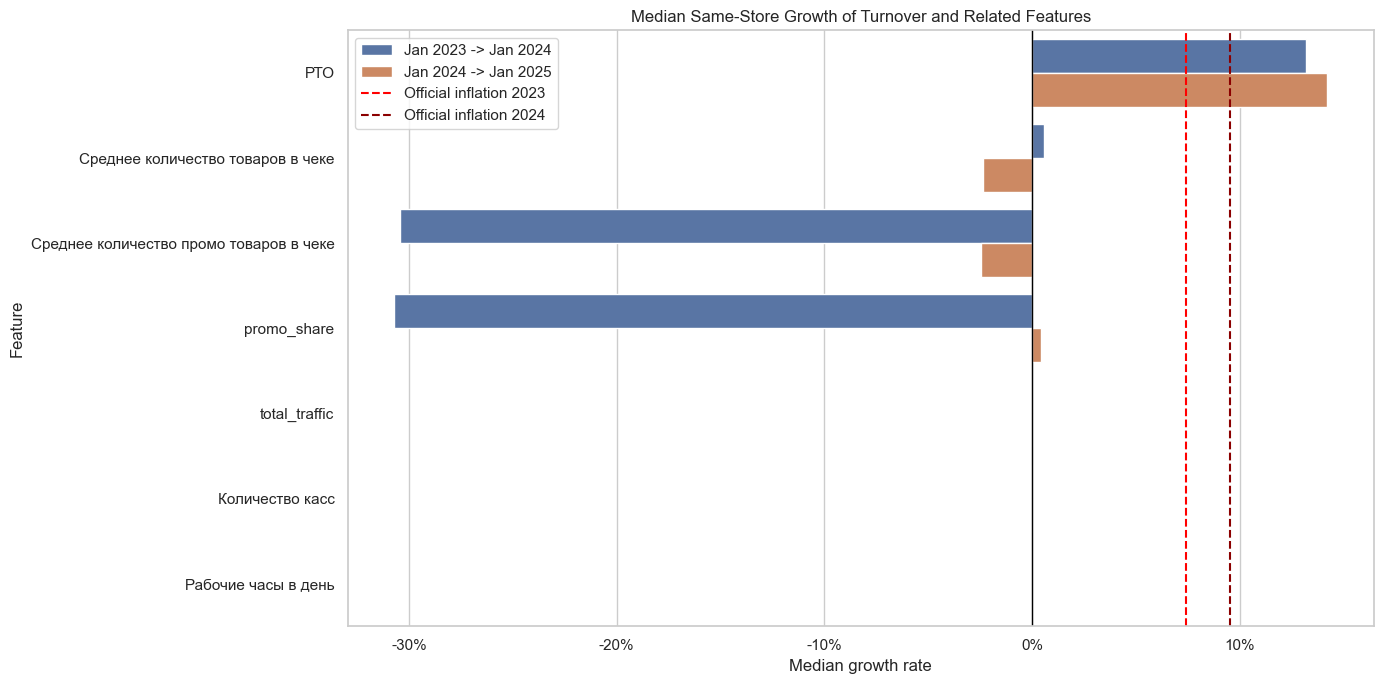

In [46]:
plt.figure(figsize=(14, 7))
sns.barplot(data=growth_comparison, x="median_growth", y="feature", hue="period")
plt.axvline(0, color="black", linewidth=1)
plt.axvline(official_inflation["Jan 2023 -> Jan 2024"], color="red", linestyle="--", label="Official inflation 2023")
plt.axvline(official_inflation["Jan 2024 -> Jan 2025"], color="darkred", linestyle="--", label="Official inflation 2024")
plt.title("Median Same-Store Growth of Turnover and Related Features")
plt.xlabel("Median growth rate")
plt.ylabel("Feature")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.legend()
plt.tight_layout()
plt.show()


In [47]:
rto_growth = growth_comparison[growth_comparison["feature"] == "РТО"][["period", "median_growth"]]
other_growth = growth_comparison[growth_comparison["feature"] != "РТО"][["period", "feature", "median_growth"]]

rto_vs_features = other_growth.merge(rto_growth, on="period", suffixes=("_feature", "_RTO"))
rto_vs_features["RTO_growth_minus_feature_growth"] = (
    rto_vs_features["median_growth_RTO"] - rto_vs_features["median_growth_feature"]
)

rto_vs_features.sort_values(["period", "RTO_growth_minus_feature_growth"], ascending=[True, False])


,period,feature,median_growth_feature,median_growth_RTO,RTO_growth_minus_feature_growth
4,Jan 2023 -> Jan 2024,promo_share,-0.307120,0.131732,0.438852
2,Jan 2023 -> Jan 2024,Среднее количество промо товаров в чеке,-0.304348,0.131732,0.436080
6,Jan 2023 -> Jan 2024,total_traffic,0.000000,0.131732,0.131732
8,Jan 2023 -> Jan 2024,Количество касс,0.000000,0.131732,0.131732
10,Jan 2023 -> Jan 2024,Рабочие часы в день,0.000000,0.131732,0.131732
0,Jan 2023 -> Jan 2024,Среднее количество товаров в чеке,0.005882,0.131732,0.125849
3,Jan 2024 -> Jan 2025,Среднее количество промо товаров в чеке,-0.024691,0.142178,0.166869
1,Jan 2024 -> Jan 2025,Среднее количество товаров в чеке,-0.023729,0.142178,0.165907
7,Jan 2024 -> Jan 2025,total_traffic,0.000000,0.142178,0.142178
9,Jan 2024 -> Jan 2025,Количество касс,0.000000,0.142178,0.142178


The additional check strengthens the interpretation. Turnover grows much faster than operational features such as traffic, working hours, number of cash registers, and the number of items in a receipt. Still, the conclusion remains cautious: the data suggests higher monetary value per purchase, but it does not provide a direct price index.


### 8.2 Hypothesis 2: Larger Stores Have Higher Turnover per Cash Register Regardless of Alcohol License

**Hypothesis:** larger stores generate more turnover per cash register — and this effect holds *within both* alcohol license groups.

This is a stronger check than simply comparing store sizes. Stores with an alcohol license tend to have a higher average receipt value, which could inflate their turnover per cash register. If larger stores also happen to have alcohol licenses more often, the area effect might just be a proxy for that. The hypothesis checks whether the area premium survives when the license group is held constant.

In [48]:
area_efficiency = (
    clean.groupby("Торговая площадь, категориальный")
    .agg(
        observations=("new_id", "size"),
        stores=("new_id", "nunique"),
        median_RTO=("РТО", "median"),
        mean_RTO=("РТО", "mean"),
        median_cash_registers=("Количество касс", "median"),
        median_RTO_per_cash_register=("rto_per_cash_register", "median"),
        mean_RTO_per_cash_register=("rto_per_cash_register", "mean"),
        median_total_traffic=("total_traffic", "median"),
    )
    .reset_index()
)

area_order = area_efficiency.sort_values("median_RTO")["Торговая площадь, категориальный"]

area_efficiency[[
    "Торговая площадь, категориальный",
    "stores",
    "median_RTO",
    "median_cash_registers",
    "median_RTO_per_cash_register",
    "median_total_traffic",
]].sort_values("median_RTO")


,"Торговая площадь, категориальный",stores,median_RTO,median_cash_registers,median_RTO_per_cash_register,median_total_traffic
1,Маленький,3871,5.972209e+07,6.0,1.025313e+07,266.0
3,Средний,10422,7.207410e+07,7.0,1.045943e+07,281.0
0,Большой,3879,1.092818e+08,9.0,1.208988e+07,305.0
2,Очень большой,485,1.854014e+08,13.0,1.441826e+07,361.0


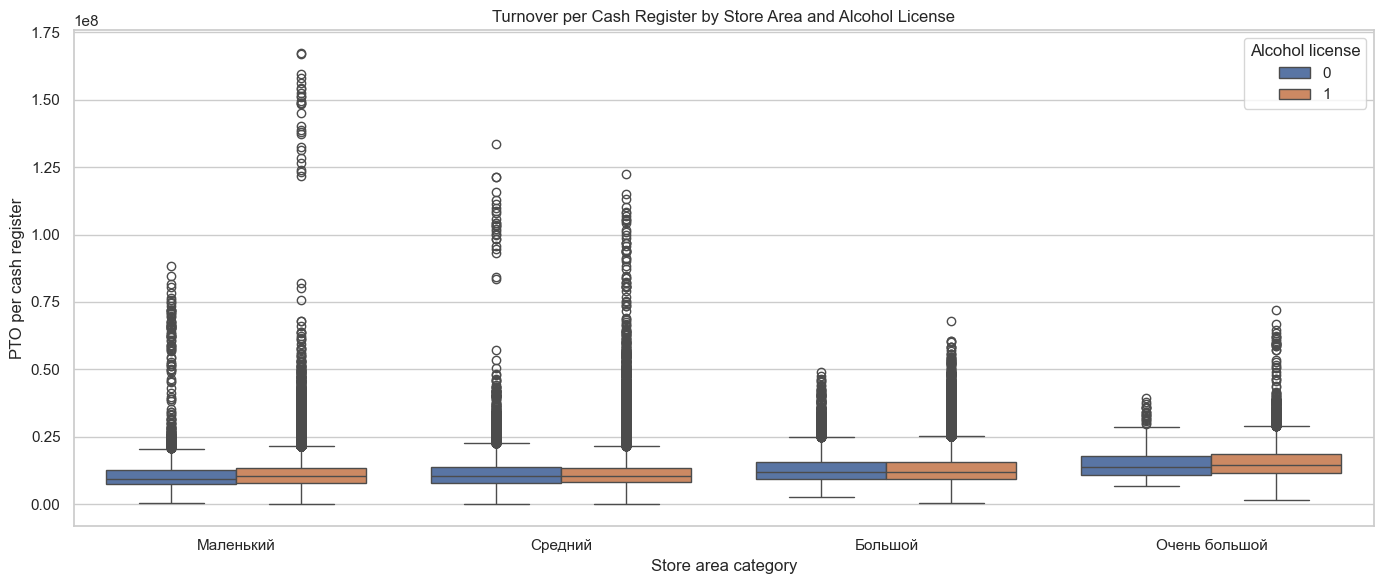

In [49]:
area_order_fixed = (
    clean.groupby("Торговая площадь, категориальный")["rto_per_cash_register"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=clean,
    x="Торговая площадь, категориальный",
    y="rto_per_cash_register",
    hue="Флаг алкогольной лицензии",
    order=area_order_fixed,
)
plt.title("Turnover per Cash Register by Store Area and Alcohol License")
plt.xlabel("Store area category")
plt.ylabel("РТО per cash register")
plt.legend(title="Alcohol license")
plt.tight_layout()
plt.show()

In [50]:
h2_table = (
    clean
    .groupby(["Торговая площадь, категориальный", "Флаг алкогольной лицензии"])["rto_per_cash_register"]
    .median()
    .unstack("Флаг алкогольной лицензии")
    .loc[area_order_fixed]
)
h2_table.columns = ["No license (0)", "Has license (1)"]
h2_table.index.name = "Store area"

smallest = area_order_fixed[0]
largest = area_order_fixed[-1]

h2_table.loc["Delta (largest − smallest)"] = (
    h2_table.loc[largest] - h2_table.loc[smallest]
)

h2_table.round(0)

,No license (0),Has license (1)
Store area,,
Маленький,9429360.0,10320255.0
Средний,10290486.0,10469637.0
Большой,12025058.0,12096332.0
Очень большой,13816048.0,14449477.0
Delta (largest − smallest),4386687.0,4129223.0


In [51]:
for license_flag in [0, 1]:
    group = clean[clean["Флаг алкогольной лицензии"] == license_flag]
    small = group[group["Торговая площадь, категориальный"] == smallest]["rto_per_cash_register"].dropna()
    large = group[group["Торговая площадь, категориальный"] == largest]["rto_per_cash_register"].dropna()
    stat, p = mannwhitneyu(large, small, alternative="greater")
    label = "No license" if license_flag == 0 else "Has license"
    print(f"{label}: Mann-Whitney U = {stat:.0f}, p = {p:.2e}")

No license: Mann-Whitney U = 3864028, p = 7.67e-106
Has license: Mann-Whitney U = 820806568, p = 0.00e+00


The second hypothesis is supported in both license groups. Median turnover per cash register increases monotonically with store area for stores without an alcohol license and for stores with one. The delta row shows that the gap between the largest and smallest format is positive in both columns. The Mann-Whitney U test confirms that the largest stores have significantly higher turnover per cash register than the smallest stores within each license group. This means the area effect is not explained by the alcohol license: larger stores are more efficient per cash register regardless of whether they sell alcohol.

## 9. Discussion / Conclusion

This project analyzed a monthly store-level dataset for Pyaterochka stores. The dataset contains store identifiers, calendar fields, turnover, store characteristics, local traffic indicators, regional information, and categorical descriptions of store area and age.

The first important finding is that a dataset can have no explicit missing values and still require serious cleanup. Several hidden data quality problems were found: impossible working hours, suspiciously low working hours, zero population values, zero traffic values, and zero cash registers. These values were treated as hidden missing or incorrect values, replaced with `NaN`, and then filled using group medians. At the same time, anomaly flags were kept to preserve information about the original data problems.

Descriptive statistics and visualizations showed that turnover is strongly right-skewed. Most stores have moderate turnover, while a smaller number of stores have very high turnover. The general overview also showed stable store coverage across months, seasonal turnover patterns, differences between store area categories, and skewed traffic distributions.

The detailed overview showed that regional total turnover is strongly affected by the number of stores in the dataset, so median turnover and store-level comparisons are more useful for comparing typical performance. Correlation and scatter plots showed that turnover is associated with store capacity indicators such as cash registers and with receipt-related variables.

The first hypothesis was partially supported: same-store January turnover growth was higher than the official inflation benchmark in both tested periods. However, this result cannot be interpreted as direct proof of food price inflation, because the dataset does not contain product-level prices, number of receipts, or average receipt value in rubles. The second hypothesis was supported in both alcohol license groups: larger stores have higher turnover per cash register regardless of whether they sell alcohol, which confirms that the area effect is not a proxy for the license.

The main limitations are the absence of product-level prices, exact store area in square meters, number of receipts, and official regional store counts. Therefore, the analysis should be interpreted as exploratory, not causal. The web interface is developed separately and presents the final report, plots, explanations, and analytical outputs in an interactive format.
